In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import random
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, Sampler, DataLoader
import numpy as np
from torch.utils.data import DataLoader, Sampler
from torch.utils.data.dataloader import default_collate
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision.utils import make_grid
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

In [4]:
import sys
from pathlib import Path

# Define the project path
PROJECT_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main')
sys.path.append(str(PROJECT_PATH))

# Define the dataset path
DATASET_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main/data')
sys.path.append(str(DATASET_PATH))

# Load Data

In [5]:
N_MFCC = 39
TIME_FRAME = 333

## HeartSoundDataSet

In [6]:
def spec_augment(spec, F=6, T=25, num_masks=2):
    """SpecAugment cho MFCC"""
    cloned = spec.clone()
    num_mel_channels, num_frames = cloned.shape[-2:]

    # Frequency masking
    for _ in range(num_masks):
        f = np.random.randint(0, F)
        f0 = np.random.randint(0, num_mel_channels - f)
        cloned[..., f0:f0+f, :] = cloned[..., f0:f0+f, :].mean()

    # Time masking
    for _ in range(num_masks):
        t = np.random.randint(0, T)
        t0 = np.random.randint(0, num_frames - t)
        cloned[..., :, t0:t0+t] = 0

    return cloned

In [7]:
import numpy as np
import h5py
import random
import torch
from pathlib import Path
import librosa  # cần import để tính delta

EPS = 1e-8

def standard_normal_variate(data):
    """Chuẩn hóa Z-score trên toàn bộ tensor."""
    mean = np.mean(data)
    std = np.std(data) + EPS
    return (data - mean) / std

class HeartSoundDataSet(torch.utils.data.Dataset):
    def __init__(self,
                 fea_path: str,              # đường dẫn file .h5
                 labels: pd.DataFrame,       # DataFrame với cột 'filename' và 'label'
                 duration: int = 5,          # giây
                 training: bool = True,
                 augment_prob=0.3,
                 delta: bool = False,
                 norm: bool = True):
        self._fea_path = fea_path
        self._h5database = None
        self._labels = labels.reset_index(drop=True)
        self._colname = ['filename', 'label']
        self._len = len(self._labels)
        self._duration = duration
        self._delta = delta
        self.train = training
        self.augment_prob = augment_prob
        self.hop_length = 15  # ms
        self.norm = norm

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
      row = self._labels.iloc[idx]
      filename = row['filename']
      target_bin = row['label']

      # Lấy key từ stem của filename
      key = Path(filename).stem if '/' in str(filename) else filename

      # Mở HDF5 nếu chưa mở
      if self._h5database is None:
          self._h5database = h5py.File(self._fea_path, 'r')

      if key not in self._h5database:
          available = list(self._h5database.keys())[:10]
          raise KeyError(f"Key '{key}' not found in HDF5. Sample keys: {available}")

      # Load feature từ HDF5
      feature = self._h5database[key][()]  # (mel_bins, T) hoặc (C, mel_bins, T)

      # Đảm bảo feature là 3D: (C, H, W)
      if feature.ndim == 2:
          feature = feature[np.newaxis, :, :]  # → (1, mel_bins, T)
      elif feature.ndim != 3:
          raise ValueError(f"Unexpected shape {feature.shape} for key '{key}'")

      # Chuẩn hóa toàn bộ tensor (nếu bật)
      if self.norm:
          feature = standard_normal_variate(feature)

      # Lấy shape hiện tại
      channels, mel_bins, num_frames = feature.shape

      # Tính độ dài mong muốn (frames)
      cycle_len = int(self._duration * 1000 / self.hop_length)

      # Crop hoặc pad để đạt đúng cycle_len
      if num_frames >= cycle_len:
          if self.train:
              #feature_tensor = spec_augment(feature_tensor, F=5, T=30, num_masks=1)
              start_ind = random.randint(0, num_frames - cycle_len)
          else:
              start_ind = (num_frames - cycle_len) // 2
          feature = feature[:, :, start_ind:start_ind + cycle_len]
      elif num_frames < cycle_len:
          pad_width = ((0, 0), (0, 0), (0, cycle_len - num_frames))
          feature = np.pad(feature, pad_width, mode='wrap')

      # === Fix quan trọng cho model gốc: Làm cho tensor luôn là 3D (mel_bins, num_frames) ===
      feature_tensor = torch.from_numpy(feature).float()  # (C, mel_bins, T)

      if self.train and np.random.rand() < self.augment_prob:
          feature_tensor = spec_augment(
              feature_tensor,
              F=1,       # Giảm từ 2 → 1 (mask ít bins hơn)
              T=8,       # Giảm từ 10 → 8 (mask ngắn hơn)
              num_masks=1
          )

      if channels > 1:  # Có delta → C=3
          # Ghép 3 channels vào chiều mel_bins → (3 * mel_bins, T) = (384, T)
          # Model sẽ view thành (B, 3, 128, T) trong forward
          feature_tensor = feature_tensor.view(channels * mel_bins, -1)  # → (384, T)
      else:
          # Không delta → squeeze về (mel_bins, T) = (128, T)
          feature_tensor = feature_tensor.squeeze(0)

      return feature_tensor, torch.tensor(target_bin, dtype=torch.long)

    def __del__(self):
        """Đóng file HDF5 khi object bị hủy (tốt cho quản lý tài nguyên)."""
        if self._h5database is not None:
            self._h5database.close()

## MinimumOccupancySampler

In [8]:
class MinimumOccupancySampler(Sampler):
    """
        samples at least one instance from each class sequentially
    """
    def __init__(self, labels, sampling_mode='over', random_state=None):
        #data_samples = labels.shape
        data_samples = len(labels)
        n_labels = len(np.unique(labels))
        label_to_idx_list, label_to_length = [], []
        self.random_state = np.random.RandomState(seed=random_state)
        for lb_idx in range(n_labels):
            label_indexes = np.where(labels == lb_idx)[0]
            self.random_state.shuffle(label_indexes)
            label_to_length.append(len(label_indexes))
            label_to_idx_list.append(label_indexes)

        self.longest_seq = max(label_to_length)
        self.data_source = np.empty((self.longest_seq, len(label_to_length)), dtype=int)
        # Each column represents one "single instance per class" data piece
        for ix, leng in enumerate(label_to_length):
            self.data_source[:leng, ix] = label_to_idx_list[ix]
        self.label_to_length = label_to_length
        self.label_to_idx_list = label_to_idx_list

        if sampling_mode == 'same':
            self.data_length = data_samples
        elif sampling_mode == 'over':  # Sample all items
            self.data_length = int(np.prod(self.data_source.shape))

    def _resample(self):
        for ix, leng in enumerate(self.label_to_length):
            leftover = self.longest_seq - leng
            random_idxs = np.random.randint(leng, size=leftover)
            self.data_source[leng:, ix] = self.label_to_idx_list[ix][random_idxs]

    def __iter__(self):
        self._resample()
        n_samples = len(self.data_source)
        random_indices = self.random_state.permutation(n_samples)
        data = np.concatenate(
            self.data_source[random_indices])[:self.data_length]
        return iter(data)

    def __len__(self):
        return self.data_length

## HeartSoundDataLoader

In [9]:
class BaseDataLoader(DataLoader):
    """
    Base class for all data loaders
    """
    def __init__(self, dataset, batch_size, shuffle, validation_split, num_workers, collate_fn=default_collate, sampler_type=None):
        self.validation_split = validation_split
        self.shuffle = shuffle

        self.batch_idx = 0
        self.n_samples = len(dataset)
        self.sampler_type = sampler_type
        self.sampler, self.valid_sampler = self._split_sampler(self.validation_split)
        self.init_kwargs = {
            'dataset': dataset,
            'batch_size': batch_size,
            'shuffle': self.shuffle,
            'collate_fn': collate_fn,
            'num_workers': num_workers
        }
        super().__init__(sampler=self.sampler, **self.init_kwargs)

    def _split_sampler(self, split):
        if split == 0.0:
            return None, None

        idx_full = np.arange(self.n_samples)

        np.random.seed(0)
        np.random.shuffle(idx_full)

        if isinstance(split, int):
            assert split > 0
            assert split < self.n_samples, "validation set size is configured to be larger than entire dataset."
            len_valid = split
        else:
            len_valid = int(self.n_samples * split)

        valid_idx = idx_full[0:len_valid]
        train_idx = np.delete(idx_full, np.arange(0, len_valid))
        if self.sampler_type == 'MinimumOccupancySampler':
            train_sampler = MinimumOccupancySampler(np.stack(self.label_df.iloc[train_idx]['label']),sampling_mode='same', random_state=100)
        else:
            train_sampler = SubsetRandomSampler(train_idx)
        valid_sampler = SubsetRandomSampler(valid_idx)

        # turn off shuffle option which is mutually exclusive with sampler
        self.shuffle = False
        self.n_samples = len(train_idx)

        return train_sampler, valid_sampler
    '''
    def split_validation(self):
        if self.valid_sampler is None:
            return None
        else:
            return DataLoader(sampler=self.valid_sampler, **self.init_kwargs)
    '''
    def split_validation(self):
        return DataLoader(
            dataset=self.val_dataset,
            batch_size=self.init_kwargs['batch_size'],
            shuffle=False,
            num_workers=self.init_kwargs['num_workers']
        )

In [10]:
class HeartSoundDataLoader(DataLoader):
    def __init__(self,
                 fea_path,
                 label_df,
                 duration,
                 batch_size,
                 delta=False,
                 norm=False,
                 shuffle=True,
                 validation_split=0.0,
                 num_workers=1,
                 training=True,
                 collate_fn=None):

        if training:
            # --- ĐOẠN SỬA ĐỔI ĐỂ CHỐNG DATA LEAKAGE ---
            # 1. Tạo cột base_id bằng cách tách bỏ phần '_augX' trong tên file
            label_df['base_id'] = label_df['filename'].apply(lambda x: Path(x).stem.split('_aug')[0])

            if validation_split > 0.0:
                unique_ids = label_df['base_id'].unique()
                train_ids, val_ids = train_test_split(unique_ids, test_size=validation_split, random_state=100)
                self.train_df = label_df[label_df['base_id'].isin(train_ids)].copy()
                self.val_df = label_df[label_df['base_id'].isin(val_ids)].copy()
            else:
                # Nếu split = 0, dùng toàn bộ label_df cho tập train
                self.train_df = label_df.copy()
                self.val_df = pd.DataFrame() # Tập val trống vì ta sẽ load riêng ở hàm main

            # 5. Xóa cột phụ base_id để tránh ảnh hưởng đến các lớp khác
            self.train_df.drop(columns=['base_id'], inplace=True)
            if not self.val_df.empty:
                self.val_df.drop(columns=['base_id'], inplace=True)
            # ------------------------------------------

            # Giữ nguyên logic khởi tạo Sampler và Dataset
            self.train_sampler = MinimumOccupancySampler(np.stack(self.train_df['label']), sampling_mode='same', random_state=100 )
            if not self.val_df.empty:
                self.val_dataset = HeartSoundDataSet(fea_path, self.val_df, duration=duration, training=False, delta=delta, norm=norm)
            else:
                self.val_dataset = None
        else:
            self.train_df = label_df
            self.train_sampler = None

        self.dataset = HeartSoundDataSet(fea_path, self.train_df, duration=duration,
                                         training=training, delta=delta, norm=norm)

        self.init_kwargs = {
            'batch_size': batch_size,
            'shuffle': False if self.train_sampler is not None else shuffle,
            'collate_fn': collate_fn,
            'num_workers': num_workers
        }
        super().__init__(sampler=self.train_sampler,
                         dataset=self.dataset,
                         **self.init_kwargs)

    def split_validation(self):
        return DataLoader(dataset=self.val_dataset, **self.init_kwargs)

=== Debug DataLoader (FINAL FIXED VERSION) ===
Label CSV columns: ['filename', 'label']
First 10 HDF5 keys: ['a0001', 'a0001_aug0', 'a0001_aug1', 'a0001_aug2', 'a0002', 'a0002_aug0', 'a0002_aug1', 'a0002_aug2', 'a0003', 'a0003_aug0']
Batch shape: torch.Size([4, 39, 333])
Targets: [1 1 1 1]
Value range: -7.194 ~ 2.585


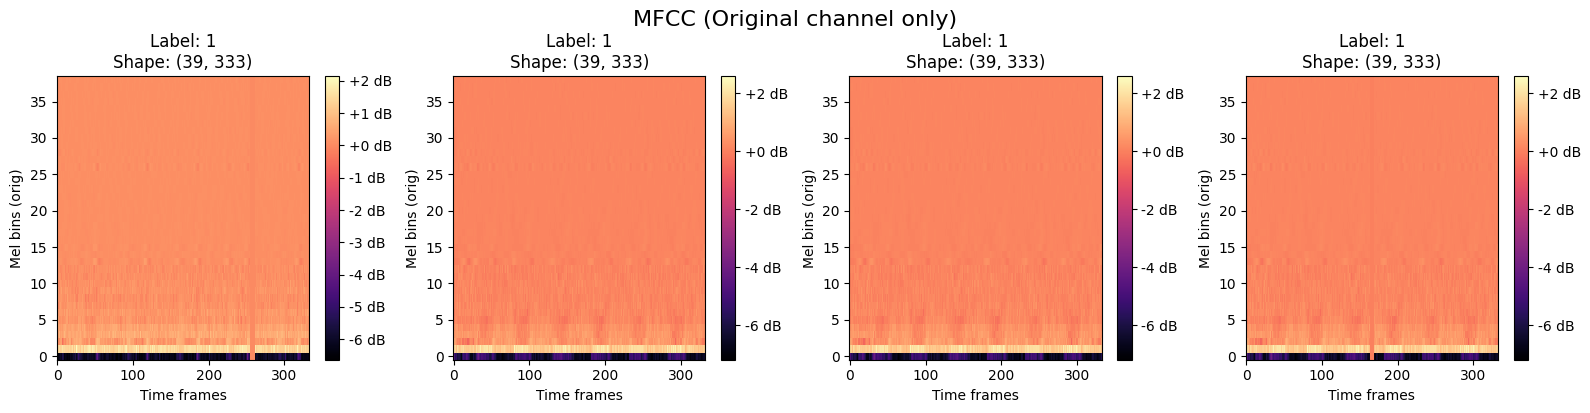

In [11]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import h5py
from pathlib import Path

print("=== Debug DataLoader (FINAL FIXED VERSION) ===")
fea_path = str(DATASET_PATH/"mfcc_train.h5")

# Load label CSV
label_df = pd.read_csv(DATASET_PATH / 'label_39_train_augmented.csv')
print("Label CSV columns:", label_df.columns.tolist())

# Sửa filename thành stem
label_df['filename'] = label_df['filename'].apply(lambda x: Path(x).stem)

# Kiểm tra HDF5 keys
with h5py.File(fea_path, 'r') as f:
    print("First 10 HDF5 keys:", list(f.keys())[:10])

# Debug dataset
debug_dataset = HeartSoundDataSet(
    fea_path=fea_path,
    labels=label_df.head(8),
    duration=5,
    training=True,
    delta=True,   # Đang bật delta → 384 mel bins
    norm=True
)

debug_loader = DataLoader(debug_dataset, batch_size=4, shuffle=True, num_workers=0)

for data, target in debug_loader:
    print(f"Batch shape: {data.shape}")
    print(f"Targets: {target.numpy()}")
    print(f"Value range: {data.min().item():.3f} ~ {data.max().item():.3f}")

    # === PHẦN VISUALIZE ĐÃ FIX ===
    plt.figure(figsize=(16, 4))
    for i in range(data.shape[0]):
        plt.subplot(1, 4, i + 1)

        spectrogram = data[i].numpy()  # shape: (384, 333) nếu delta=True, hoặc (128, 333) nếu delta=False

        # Nếu dùng delta → tách ra để chỉ vẽ channel gốc (128 mel bins đầu tiên)
        if spectrogram.shape[0] == 384:  # 3 * 128
            img = spectrogram[:128, :]   # Chỉ lấy phần logmel gốc (channel 0)
        else:
            img = spectrogram            # Không delta → vẽ hết

        plt.imshow(img, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
        plt.title(f"Label: {target[i].item()}\nShape: {img.shape}")
        plt.xlabel("Time frames")
        plt.ylabel("Mel bins (orig)")
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()

    plt.suptitle("MFCC (Original channel only)", fontsize=16, y=1.02)
    plt.show()
    break

# ConfigParser

In [12]:
# parse_config.py
import os
import logging
from pathlib import Path
from datetime import datetime
import argparse
import collections
import importlib.util

class ConfigParser:
    def __init__(self, config_dict, resume=None, modification=None, run_id=None):
        self._config = config_dict
        self.resume = resume

        # Apply CLI modifications
        if modification:
            for key_path, value in modification.items():
                keys = key_path.split(';')
                d = self._config
                for k in keys[:-1]:
                    d = d[k]
                d[keys[-1]] = value

        # Setup save and log directories
        save_dir = Path(self.config['trainer']['save_dir'])
        exper_name = self.config['name']
        if run_id is None:
            run_id = datetime.now().strftime(r'%m%d_%H%M%S')
        self._save_dir = save_dir / 'models' / exper_name / run_id
        self._log_dir = save_dir / 'log' / exper_name / run_id

        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.log_dir.mkdir(parents=True, exist_ok=True)

        # Optional: setup logging
        # setup_logging(self.log_dir)

    @classmethod
    def from_args(cls, parser, options=None):
        """
        parser: argparse.ArgumentParser đã được add_argument xong
        options: list các CustomArgs để override
        """
        if options is None:
            options = []

        # Parse arguments (an toàn cho cả terminal và notebook)
        args = parser.parse_args()

        # Xử lý device
        if args.device is not None:
            os.environ["CUDA_VISIBLE_DEVICES"] = args.device

        # Xử lý resume
        if args.resume is not None:
            resume = Path(args.resume)
            cfg_fname = resume.parent / 'config.py'  # hoặc .json nếu bạn dùng cả 2
        else:
            resume = None
            assert args.config is not None, "Phải chỉ định -c config.py"
            cfg_fname = Path(args.config)

        # Đọc config từ file .py
        if not cfg_fname.exists():
            raise FileNotFoundError(f"Không tìm thấy config file: {cfg_fname}")

        if cfg_fname.suffix == '.py':
            spec = importlib.util.spec_from_file_location("config_module", cfg_fname)
            config_module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(config_module)
            if not hasattr(config_module, 'config'):
                raise ValueError(f"File {cfg_fname} phải định nghĩa biến 'config'")
            config_dict = config_module.config
        else:
            raise ValueError("Chỉ hỗ trợ file config .py")

        # Parse custom CLI overrides
        CustomArgs = collections.namedtuple('CustomArgs', 'flags type target')
        modification = {}
        for opt in options:
            for flag in opt.flags:
                arg_name = flag.lstrip('-').replace('-', '_')
                if hasattr(args, arg_name) and getattr(args, arg_name) is not None:
                    modification[opt.target] = opt.type(getattr(args, arg_name))

        return cls(config_dict, resume, modification)

    def init_obj(self, name, module, *args, **kwargs):
        module_name = self[name]['type']
        module_args = dict(self[name]['args'])
        module_args.update(kwargs)
        if isinstance(module, dict):
            obj_class = module[module_name]
        else:
            obj_class = getattr(module, module_name)

        return obj_class(*args, **module_args)

    def init_ftn(self, name, module, *args, **kwargs):
        from functools import partial
        module_name = self[name]['type']
        module_args = dict(self[name]['args'])
        module_args.update(kwargs)
        if isinstance(module, dict):
            obj_class = module[module_name]
        else:
            obj_class = getattr(module, module_name)

        return obj_class(*args, **module_args)

    def __getitem__(self, name):
        return self.config[name]

    def get_logger(self, name, verbosity=2):
        logger = logging.getLogger(name)
        logger.setLevel({0: logging.WARNING, 1: logging.INFO, 2: logging.DEBUG}[verbosity])
        return logger

    @property
    def config(self):
        return self._config

    @property
    def save_dir(self):
        return self._save_dir

    @property
    def log_dir(self):
        return self._log_dir

# Logging

In [13]:
def mixup_data(x, y, alpha=0.2):
    """Mixup augmentation"""
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [14]:
import importlib
from datetime import datetime


class TensorboardWriter():
    def __init__(self, log_dir, logger, enabled):
        self.writer = None
        self.selected_module = ""

        if enabled:
            log_dir = str(log_dir)

            # Retrieve vizualization writer.
            succeeded = False
            for module in ["torch.utils.tensorboard", "tensorboardX"]:
                try:
                    self.writer = importlib.import_module(module).SummaryWriter(log_dir)
                    succeeded = True
                    break
                except ImportError:
                    succeeded = False
                self.selected_module = module

            if not succeeded:
                message = "Warning: visualization (Tensorboard) is configured to use, but currently not installed on " \
                    "this machine. Please install TensorboardX with 'pip install tensorboardx', upgrade PyTorch to " \
                    "version >= 1.1 to use 'torch.utils.tensorboard' or turn off the option in the 'config.json' file."
                logger.warning(message)

        self.step = 0
        self.mode = ''

        self.tb_writer_ftns = {
            'add_scalar', 'add_scalars', 'add_image', 'add_images', 'add_audio',
            'add_text', 'add_histogram', 'add_pr_curve', 'add_embedding'
        }
        self.tag_mode_exceptions = {'add_histogram', 'add_embedding'}
        self.timer = datetime.now()

    def set_step(self, step, mode='train'):
        self.mode = mode
        self.step = step
        if step == 0:
            self.timer = datetime.now()
        else:
            duration = datetime.now() - self.timer
            self.add_scalar('steps_per_sec', 1 / duration.total_seconds())
            self.timer = datetime.now()

    def __getattr__(self, name):
        """
        If visualization is configured to use:
            return add_data() methods of tensorboard with additional information (step, tag) added.
        Otherwise:
            return a blank function handle that does nothing
        """
        if name in self.tb_writer_ftns:
            add_data = getattr(self.writer, name, None)

            def wrapper(tag, data, *args, **kwargs):
                if add_data is not None:
                    # add mode(train/valid) tag
                    if name not in self.tag_mode_exceptions:
                        tag = '{}/{}'.format(tag, self.mode)
                    add_data(tag, data, self.step, *args, **kwargs)
            return wrapper
        else:
            # default action for returning methods defined in this class, set_step() for instance.
            try:
                attr = object.__getattr__(name)
            except AttributeError:
                raise AttributeError("type object '{}' has no attribute '{}'".format(self.selected_module, name))
            return attr

#Loss

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        weight = torch.tensor(
            [self.alpha, 1 - self.alpha], device=inputs.device
        ).float()   # [w_normal, w_abnormal]
        ce_loss = F.cross_entropy(inputs, targets, weight=weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [16]:
class CBFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999, gamma=2.0):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.array(effective_num)
        self.weights = weights / np.sum(weights) * len(samples_per_class)
        self.gamma = gamma

    def forward(self, inputs, targets):
        weights = torch.tensor(self.weights, device=inputs.device).float()
        ce_loss = F.cross_entropy(inputs, targets, weight=weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

# Sử dụng:
# samples_per_class = [số_mẫu_abnormal, số_mẫu_normal]

In [17]:
class WeightedCELoss(nn.Module):
    """
    Weighted Cross Entropy Loss
    """
    def __init__(self, weights):
        super().__init__()
        self.register_buffer(
            "weights", torch.tensor(weights, dtype=torch.float)
        )

    def forward(self, logits, target):
        return F.cross_entropy(
            logits,
            target,
            weight=self.weights
        )


In [18]:
class CostSensitiveLoss(nn.Module):
    """
    Cost-sensitive Cross Entropy
    FN (abnormal → normal) bị phạt nặng hơn FP
    """
    def __init__(self, fn_cost=2.5, fp_cost=1.0):
        super().__init__()
        self.fn_cost = fn_cost
        self.fp_cost = fp_cost

    def forward(self, logits, target):
        weights = torch.tensor(
            [self.fp_cost, self.fn_cost],
            device=logits.device
        )

        return F.cross_entropy(
            logits,
            target,
            weight=weights
        )

In [19]:
class AsymmetricFocalLoss(nn.Module):
    """
    Focal Loss với gamma khác nhau cho positive/negative.
    gamma_neg cao hơn → phạt nặng hơn khi predict FP → tăng Precision → tăng F1.
    """
    def __init__(self, gamma_pos=0.5, gamma_neg=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma_pos = gamma_pos   # Nhẹ tay với Abnormal (giữ Sensitivity)
        self.gamma_neg = gamma_neg   # Mạnh tay với Normal bị predict sai (giảm FP)
        self.ls = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, label_smoothing=self.ls, reduction='none')
        probs = torch.softmax(logits, dim=1)
        pt = probs[torch.arange(len(targets)), targets]
        gamma = torch.where(targets == 1,
                            torch.full_like(pt, self.gamma_pos),
                            torch.full_like(pt, self.gamma_neg))
        loss = ((1 - pt) ** gamma) * ce
        return loss.mean()

In [20]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.5, label_smoothing=0.1, focal_weight=0.7):
        self.focal_loss = ImprovedFocalLoss(alpha, gamma, label_smoothing)
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

In [21]:
import torch.nn.functional as F


def nll_loss(output, target):
    return F.nll_loss(output, target)

def ce_loss(output, target):
    return F.cross_entropy(output, target)

def focal_loss(output, target, alpha=0.75, gamma=2.0):
    return FocalLoss(alpha=alpha, gamma=gamma)(output, target)

# Dùng khi tỷ lệ abnormal ≪ normal.
def weighted_ce_loss(output, target, weights):
    return WeightedCELoss(weights)(output, target)

# Đặc biệt phù hợp bài toán y sinh, nơi bỏ sót bệnh (FN) nguy hiểm hơn FP.
def cost_sensitive_loss(output, target, fn_cost=2.5, fp_cost=1.0):
    return CostSensitiveLoss(fn_cost, fp_cost)(output, target)

LOSS_REGISTRY = {
    "ce_loss": lambda: nn.CrossEntropyLoss(),
    "focal_loss": lambda: FocalLoss(alpha=0.75, gamma=2.0),
    "cost_sensitive_loss": lambda: CostSensitiveLoss(fn_cost=2.5, fp_cost=1.0),
    "weighted_ce_loss": lambda weights: WeightedCELoss(weights),
}

# Metric

In [22]:
import torch


def accuracy(output, target):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        assert pred.shape[0] == len(target)
        correct = 0
        correct += torch.sum(pred == target).item()
    return correct / len(target)

import torch

def sensitivity(output, target, positive_class=1, eps=1e-8):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        tp = torch.sum((pred == positive_class) & (target == positive_class)).item()
        fn = torch.sum((pred != positive_class) & (target == positive_class)).item()
    return tp / (tp + fn + eps)


def f1_score(output, target, positive_class=1, eps=1e-8):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)

        tp = torch.sum((pred == positive_class) & (target == positive_class)).item()
        fp = torch.sum((pred == positive_class) & (target != positive_class)).item()
        fn = torch.sum((pred != positive_class) & (target == positive_class)).item()

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)

        f1 = 2 * precision * recall / (precision + recall + eps)

    return f1

In [23]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# Warmup scheduler
class WarmupCosineScheduler:
    """
    Warmup tuyến tính + Cosine decay một chiều (KHÔNG restart).
    Thêm get_last_lr() để tương thích với Trainer.
    """
    def __init__(self, optimizer, warmup_epochs=5, total_epochs=120, lr_min=1e-6):
        self.optimizer      = optimizer
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.lr_min         = lr_min
        self.base_lr        = optimizer.param_groups[0]['lr']
        self._current_lr    = self.base_lr

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Tuyến tính từ lr_min → base_lr
            lr = self.lr_min + (self.base_lr - self.lr_min) * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine một chiều: base_lr → lr_min (KHÔNG restart)
            progress = (epoch - self.warmup_epochs) / max(
                self.total_epochs - self.warmup_epochs, 1
            )
            progress = min(progress, 1.0)           # clamp tránh vượt 1.0
            lr = self.lr_min + (self.base_lr - self.lr_min) * 0.5 * (
                1.0 + np.cos(np.pi * progress)
            )
        self._current_lr = lr
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr

    def get_last_lr(self):
        return [self._current_lr]


In [24]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        else:
            self.best_score = val_loss
            self.counter = 0
        return False

# Model


In [25]:
import torch.nn as nn
import numpy as np
from abc import abstractmethod


class BaseModel(nn.Module):
    """
    Base class for all models
    """
    @abstractmethod
    def forward(self, *inputs):
        """
        Forward pass logic

        :return: Model output
        """
        raise NotImplementedError

    def __str__(self):
        """
        Model prints with number of trainable parameters
        """
        model_parameters = filter(lambda p: p.requires_grad, self.parameters())
        params = sum([np.prod(p.size()) for p in model_parameters])
        return super().__str__() + '\nTrainable parameters: {}'.format(params)

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# functions of initializing layers
def init_layer(layer):
    """Initialize a Linear or Convolutional layer."""
    nn.init.xavier_uniform_(layer.weight)

    if hasattr(layer, 'bias'):
        if layer.bias is not None:
            layer.bias.data.fill_(0.)

def init_bn(bn):
    """Initialize a Batchnorm layer."""
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.)

def init_rnn(rnn):
    """init_rnn
    Initialized RNN weights, independent of type GRU/LSTM/RNN
    :param rnn: the rnn model
    """
    for name, param in rnn.named_parameters():
        if 'bias' in name:
            nn.init.constant_(param, 0.0)
        elif 'weight' in name:
            nn.init.xavier_uniform_(param)

def reset_parameters(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            init_layer(module)
        elif isinstance(module, nn.Linear):
            init_layer(module)
        elif isinstance(module, nn.BatchNorm2d):
            init_bn(module)
        elif isinstance(module, nn.LSTM):
            init_rnn(module)


## Simple CNN Block

In [27]:
class SimpleHeartSoundCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleHeartSoundCNN, self).__init__()

        # Layer 1: Conv2D -> BatchNorm -> MaxPooling
        # Input: (B, 1, 13, 100)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Kết quả ~ (B, 8, 6, 50)

        # Layer 2: Conv2D -> BatchNorm -> MaxPooling
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Kết quả ~ (B, 16, 3, 25)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1) # Kết quả (B, 16, 1, 1)

        # Dropout & Dense (Output)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(16, num_classes)

    def forward(self, x):
        # Đảm bảo input là (B, 1, 13, 100)
        if x.dim() == 3:
            x = x.unsqueeze(1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

## Lightweight CNN Architecture

In [28]:
class DSConvBlock(nn.Module):
    """Depthwise Separable Conv — đơn giản, dễ quantize INT8."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class LiteSEBlock(nn.Module):
    """SE Block thu gọn: channels=64, reduction=8 → chỉ 1,024 params."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, _, _ = x.shape
        s = self.gap(x).view(B, C)
        return x * self.fc(s).view(B, C, 1, 1)

In [29]:
class LightweightHeartSoundCNN(nn.Module):
    def __init__(self, num_classes=2, in_channel=1, dropout=0.5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channel, 24, kernel_size=(5, 5), stride=1, padding=2, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU6(inplace=True),
            nn.Dropout2d(0.1)
        )
        self.stage1 = nn.Sequential(
            DSConvBlock(24, 32),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.stage2 = nn.Sequential(
            DSConvBlock(32, 48),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.stage3   = DSConvBlock(48, 48)
        self.se       = LiteSEBlock(48, reduction=4)
        self.gap      = nn.AdaptiveAvgPool2d(1)

        # Bổ sung các lớp còn thiếu để forward không lỗi
        self.bn_head  = nn.BatchNorm1d(48)
        self.dropout_layer = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(48, 16),
            nn.ReLU6(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(16, num_classes)
        )

        # Gọi hàm khởi tạo trọng số
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 39, 333)
        if x.dim() == 3:
            x = x.unsqueeze(1)          # (B, 1, 39, 333)

        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.se(x)
        x = self.gap(x).flatten(1)      # (B, 48)

        x = self.bn_head(x)
        x = self.dropout_layer(x)
        return self.classifier(x)

    def __str__(self):
        params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return super().__str__() + f'\nTrainable parameters: {params:,}'

## MobileNet

In [30]:
import torchvision.models as models

class MobileNetV3_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1, dropout=0.2):
        super().__init__()
        # Sử dụng mobilenet_v3_small để tối ưu tốc độ
        self.model = models.mobilenet_v3_small(weights=None)

        # Sửa input channel (mặc định là 3 thành in_channel)
        orig_conv = self.model.features[0][0]
        self.model.features[0][0] = nn.Conv2d(in_channel, orig_conv.out_channels,
                                              kernel_size=3, stride=2, padding=1, bias=False)

        # Sửa output layer
        in_features = self.model.classifier[3].in_features
        self.model.classifier[3] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        return self.model(x)

## ShuffleNet

In [31]:
class ShuffleNetV2_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        self.model = models.shufflenet_v2_x1_0(weights=None)

        # Sửa Conv1
        self.model.conv1[0] = nn.Conv2d(in_channel, 24, kernel_size=3, stride=2, padding=1, bias=False)

        # Sửa FC
        self.model.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        return self.model(x)

### ShuffleNetV2_Tiny

In [32]:
import torch
import torch.nn as nn
from base import BaseModel # Giả định bạn đang dùng template PyTorch-Project-Template

def channel_shuffle(x, groups):
    batchsize, num_channels, height, width = x.data.size()
    channels_per_group = num_channels // groups
    x = x.view(batchsize, groups, channels_per_group, height, width)
    x = torch.transpose(x, 1, 2).contiguous()
    x = x.view(batchsize, -1, height, width)
    return x

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        branch_features = oup // 2

        if self.stride > 1:
            # Nhánh 1: Downsample
            self.branch1 = nn.Sequential(
                nn.Conv2d(inp, inp, 3, stride, 1, groups=inp, bias=False),
                nn.BatchNorm2d(inp),
                nn.Conv2d(inp, branch_features, 1, 1, 0, bias=False),
                nn.BatchNorm2d(branch_features),
                nn.ReLU(inplace=True),
            )
        else:
            self.branch1 = nn.Sequential()

        # Nhánh 2: Depthwise + Pointwise
        self.branch2 = nn.Sequential(
            nn.Conv2d(inp if stride > 1 else branch_features, branch_features, 1, 1, 0, bias=False),
            nn.BatchNorm2d(branch_features),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_features, branch_features, 3, stride, 1, groups=branch_features, bias=False),
            nn.BatchNorm2d(branch_features),
            nn.Conv2d(branch_features, branch_features, 1, 1, 0, bias=False),
            nn.BatchNorm2d(branch_features),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        if self.stride == 1:
            x1, x2 = x.chunk(2, dim=1)
            out = torch.cat((x1, self.branch2(x2)), dim=1)
        else:
            out = torch.cat((self.branch1(x) , self.branch2(x)), dim=1)
        return channel_shuffle(out, 2)

class ShuffleNetV2_Tiny(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        # Cấu hình siêu mỏng để đạt ~8k tham số
        # Stage: [Số lần lặp], Out_channels: [Số kênh]
        self.stage_repeats = [2, 2, 2]
        self.stage_out_channels = [12, 24, 48, 96, 128] # Ép số kênh xuống cực thấp

        # 1. Conv1 đầu tiên
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channel, self.stage_out_channels[0], 3, 2, 1, bias=False),
            nn.BatchNorm2d(self.stage_out_channels[0]),
            nn.ReLU(inplace=True),
        )

        # 2. Maxpool
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 3. Các Stages
        stages = []
        input_channels = self.stage_out_channels[0]
        for idxstage in range(len(self.stage_repeats)):
            num_repeat = self.stage_repeats[idxstage]
            output_channels = self.stage_out_channels[idxstage + 1]

            # Khối đầu tiên của stage luôn có stride=2
            stages.append(InvertedResidual(input_channels, output_channels, 2))
            input_channels = output_channels

            # Các khối lặp lại tiếp theo có stride=1
            for _ in range(num_repeat - 1):
                stages.append(InvertedResidual(input_channels, output_channels, 1))

        self.features = nn.Sequential(*stages)

        # 4. Lớp kết thúc (Conv5 + Global Average Pool + FC)
        self.conv5 = nn.Sequential(
            nn.Conv2d(self.stage_out_channels[-2], self.stage_out_channels[-1], 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.stage_out_channels[-1]),
            nn.ReLU(inplace=True),
        )

        self.fc = nn.Linear(self.stage_out_channels[-1], num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1) # [B, H, W] -> [B, 1, H, W]
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.features(x)
        x = self.conv5(x)
        x = x.mean([2, 3]) # Global Average Pooling
        x = self.fc(x)
        return x

In [33]:
class ShuffleNetV2_Tiny(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        # Cấu hình siêu mỏng để đạt ~8k tham số
        # Stage: [Số lần lặp], Out_channels: [Số kênh]
        self.stage_repeats = [2, 2, 2]
        self.stage_out_channels = [12, 24, 48, 96, 128] # Ép số kênh xuống cực thấp

        # 1. Conv1 đầu tiên
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channel, self.stage_out_channels[0], 3, 2, 1, bias=False),
            nn.BatchNorm2d(self.stage_out_channels[0]),
            nn.ReLU(inplace=True),
        )

        # 2. Maxpool
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 3. Các Stages
        stages = []
        input_channels = self.stage_out_channels[0]
        for idxstage in range(len(self.stage_repeats)):
            num_repeat = self.stage_repeats[idxstage]
            output_channels = self.stage_out_channels[idxstage + 1]

            # Khối đầu tiên của stage luôn có stride=2
            stages.append(InvertedResidual(input_channels, output_channels, 2))
            input_channels = output_channels

            # Các khối lặp lại tiếp theo có stride=1
            for _ in range(num_repeat - 1):
                stages.append(InvertedResidual(input_channels, output_channels, 1))

        self.features = nn.Sequential(*stages)

        # 4. Lớp kết thúc (Conv5 + Global Average Pool + FC)
        self.conv5 = nn.Sequential(
            nn.Conv2d(self.stage_out_channels[-2], self.stage_out_channels[-1], 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.stage_out_channels[-1]),
            nn.ReLU(inplace=True),
        )

        self.fc = nn.Linear(self.stage_out_channels[-1], num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1) # [B, H, W] -> [B, 1, H, W]
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.features(x)
        x = self.conv5(x)
        x = x.mean([2, 3]) # Global Average Pooling
        x = self.fc(x)
        return x

### ShuffleNetV2_Nano

In [34]:
class ShuffleNetV2_Nano(BaseModel):
    def __init__(self, num_classes=2, in_channel=1, dropout_rate=0.3):
        super().__init__()
        self.stage_repeats = [2, 2, 2]
        self.stage_out_channels = [8, 16, 32, 64, 64]

        # 1. Conv1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channel, self.stage_out_channels[0], 3, 2, 1, bias=False),
            nn.BatchNorm2d(self.stage_out_channels[0]),
            nn.ReLU(inplace=True),
        )

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 2. Stages
        stages = []
        input_channels = self.stage_out_channels[0]
        for idxstage in range(len(self.stage_repeats)):
            num_repeat = self.stage_repeats[idxstage]
            output_channels = self.stage_out_channels[idxstage + 1]
            stages.append(InvertedResidual(input_channels, output_channels, 2))
            input_channels = output_channels
            for _ in range(num_repeat - 1):
                stages.append(InvertedResidual(input_channels, output_channels, 1))

        self.features = nn.Sequential(*stages)

        # 3. Conv5
        self.conv5 = nn.Sequential(
            nn.Conv2d(self.stage_out_channels[-2], self.stage_out_channels[-1], 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.stage_out_channels[-1]),
            nn.ReLU(inplace=True),
        )

        # 4. Dropout trước FC — đặt SAU global avg pool, TRƯỚC linear
        #    Không thêm param, chỉ zero ngẫu nhiên activations lúc train
        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc = nn.Linear(self.stage_out_channels[-1], num_classes)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.features(x)
        x = self.conv5(x)
        x = x.mean([2, 3])   # Global Average Pooling → (B, 64)
        x = self.dropout(x)  # Dropout tại đây: không ảnh hưởng số param
        x = self.fc(x)
        return x

## SqueezeNet

### SqueezeNet_Custom

In [35]:
class SqueezeNet_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        self.model = models.squeezenet1_1(weights=None)
        # Sửa Conv1
        self.model.features[0] = nn.Conv2d(in_channel, 64, kernel_size=3, stride=2)
        # Sửa Classifier
        self.model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
        self.model.num_classes = num_classes

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        return self.model(x)

### SqueezeNet_Tiny

In [36]:
class DepthwiseSeparableBlock(nn.Module):
    """
    Depthwise Separable Convolution Block
    DWConv (groups=in_c) → BN → ReLU → PWConv (1x1) → BN → ReLU
    Params = in_c*k*k + in_c + in_c*out_c + out_c  (bias=False)
    """
    def __init__(self, in_c: int, out_c: int, stride: int = 1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_c, in_c, kernel_size=3, stride=stride,
                      padding=1, groups=in_c, bias=False),
            nn.BatchNorm2d(in_c),
            nn.ReLU6(inplace=True),           # ReLU6: ổn định hơn ReLU trên model nhỏ
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU6(inplace=True),
        )

    def forward(self, x):
        return self.pw(self.dw(x))


class SqueezeNet_Tiny(BaseModel):
    """
    SqueezeNet_Tiny — Lightweight Heart Sound Classifier
    Total params: ~7,634 (≈8K)

    Architecture:
        Conv1 (1→12, k=3, s=2)          →  88 params
        DS-Block1 (12→24, s=2)           →  444 params
        DS-Block2 (24→48, s=2)           →  1,392 params
        DS-Block3 (48→96, s=2)           →  5,424 params
        GlobalAvgPool → Dropout(0.3) → FC(96→2)  → 194 params
        ─────────────────────────────────────────
        TOTAL                            ≈ 7,634 params
    """
    def __init__(self, num_classes: int = 2, in_channel: int = 1,
                 dropout_rate: float = 0.3):
        super().__init__()

        # --- Stem ---
        self.stem = nn.Sequential(
            nn.Conv2d(in_channel, 12, kernel_size=3, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(12),
            nn.ReLU6(inplace=True),
        )

        # --- 3 Depthwise-Separable Blocks (stride=2 để downsample) ---
        self.ds1 = DepthwiseSeparableBlock(12, 24, stride=2)
        self.ds2 = DepthwiseSeparableBlock(24, 48, stride=2)
        self.ds3 = DepthwiseSeparableBlock(48, 96, stride=2)

        # --- Head ---
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # Global Average Pooling → (B, 96, 1, 1)
            nn.Flatten(),              # → (B, 96)
            nn.Dropout(p=dropout_rate),
            nn.Linear(96, num_classes),
        )

        # --- Weight init (quan trọng cho model nhỏ) ---
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)        # (B, H, W) → (B, 1, H, W)
        x = self.stem(x)
        x = self.ds1(x)
        x = self.ds2(x)
        x = self.ds3(x)
        x = self.head(x)
        return x

## Inception

### InceptionV3_Custom

In [37]:
class InceptionV3_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        # InceptionV3 yêu cầu input size tối thiểu 299x299.
        # Bạn có thể cần dùng F.interpolate để resize input MFCC lên 299x299
        self.model = models.inception_v3(weights=None, aux_logits=False)
        self.model.Conv2d_1a_3x3.conv = nn.Conv2d(in_channel, 32, kernel_size=3, stride=2, bias=False)
        self.model.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        # Resize nếu cần: x = F.interpolate(x, size=(299, 299))
        return self.model(x)

### Inception_Tiny

In [38]:
# ============================================================
# Inception_Tiny — ~8,186 params
# Giữ đúng tinh thần Inception: multi-scale feature extraction
# (branch 1x1 / 1x1→3x3 / 1x1→3x3→3x3 / pool→1x1)
# Phù hợp MFCC input: (B, 1, 39, 333)
# ============================================================

class TinyInceptionModule(nn.Module):
    """
    Inception module thu nhỏ với 4 nhánh song song:
    ┌─ Branch1: 1×1 conv                          (capture local features)
    ├─ Branch2: 1×1 → 3×3 conv                    (medium receptive field)
    ├─ Branch3: 1×1 → 3×3 → 3×3 conv             (large receptive field, thay 5×5)
    └─ Branch4: MaxPool 3×3 → 1×1 conv            (pooling features)
    Output = concat([br1, br2, br3, br4], dim=1)
    """
    def __init__(self, in_c: int,
                 b1: int,                          # Branch1 out
                 b2_reduce: int, b2: int,          # Branch2 bottleneck → out
                 b3_reduce: int, b3: int,          # Branch3 bottleneck → out
                 pool_proj: int):                  # Branch4 out
        super().__init__()

        # Branch 1: 1×1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_c, b1, kernel_size=1, bias=False),
            nn.BatchNorm2d(b1),
            nn.ReLU6(inplace=True),
        )

        # Branch 2: 1×1 → 3×3
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_c, b2_reduce, kernel_size=1, bias=False),
            nn.BatchNorm2d(b2_reduce),
            nn.ReLU6(inplace=True),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(b2),
            nn.ReLU6(inplace=True),
        )

        # Branch 3: 1×1 → 3×3 → 3×3  (tương đương 5×5 nhưng ít params hơn)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_c, b3_reduce, kernel_size=1, bias=False),
            nn.BatchNorm2d(b3_reduce),
            nn.ReLU6(inplace=True),
            nn.Conv2d(b3_reduce, b3, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(b3),
            nn.ReLU6(inplace=True),
            nn.Conv2d(b3, b3, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(b3),
            nn.ReLU6(inplace=True),
        )

        # Branch 4: MaxPool → 1×1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_c, pool_proj, kernel_size=1, bias=False),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU6(inplace=True),
        )

        self.out_channels = b1 + b2 + b3 + pool_proj

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)   # concat theo channel


class Inception_Tiny(BaseModel):
    """
    Inception_Tiny — Multi-scale Heart Sound Classifier
    Total params: ~8,186

    Flow:
        Input (B,1,39,333)
        → Stem Conv (1→8, k=3, s=2)           →  (B, 8, 20, 167)
        → MaxPool (k=3, s=2)                   →  (B, 8, 10, 84)
        → Inception Module 1 (8→16)            →  (B, 16, 10, 84)
        → MaxPool (k=3, s=2)                   →  (B, 16, 5, 42)
        → Inception Module 2 (16→32)           →  (B, 32, 5, 42)
        → MaxPool (k=3, s=2)                   →  (B, 32, 3, 21)
        → Inception Module 3 (32→53)           →  (B, 53, 3, 21)
        → GlobalAvgPool                        →  (B, 53)
        → Dropout(0.3) → FC(53→2)             →  (B, 2)
    """
    def __init__(self, num_classes: int = 2, in_channel: int = 1,
                 dropout_rate: float = 0.3):
        super().__init__()

        # --- Stem ---
        self.stem = nn.Sequential(
            nn.Conv2d(in_channel, 8, kernel_size=3, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # --- Inception Module 1: 8 → 16 channels ---
        self.inception1 = TinyInceptionModule(
            in_c=8,
            b1=4, b2_reduce=4, b2=6, b3_reduce=2, b3=4, pool_proj=2
        )  # out=16, params=580

        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Inception Module 2: 16 → 32 channels ---
        self.inception2 = TinyInceptionModule(
            in_c=16,
            b1=8, b2_reduce=6, b2=12, b3_reduce=4, b3=8, pool_proj=4
        )  # out=32, params=1,964

        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Inception Module 3: 32 → 53 channels ---
        self.inception3 = TinyInceptionModule(
            in_c=32,
            b1=14, b2_reduce=10, b2=20, b3_reduce=5, b3=14, pool_proj=5
        )  # out=53, params=5,446

        # --- Head ---
        final_channels = self.inception3.out_channels   # 53
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(final_channels, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)     # (B, H, W) → (B, 1, H, W)
        x = self.stem(x)
        x = self.inception1(x)
        x = self.pool1(x)
        x = self.inception2(x)
        x = self.pool2(x)
        x = self.inception3(x)
        x = self.head(x)
        return x

## GoogleNet

### GoogleNet_Custom

In [39]:
class GoogleNet_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        # Lưu ý: GoogleNet của torchvision cần input tối thiểu thường là 224x224
        # Với 39x333, ta tắt aux_logits
        self.model = models.googlenet(weights=None, aux_logits=False)
        self.model.conv1.conv = nn.Conv2d(in_channel, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        return self.model(x)

### GoogLeNet_Tiny

In [40]:
class GoogLeNetInceptionModule(nn.Module):
    """
    Inception Module theo đúng cấu trúc GoogLeNet-V1 (Szegedy et al., 2014)
    4 nhánh song song:
    ┌─ Branch1: 1×1 conv                     (dimensionality reduction)
    ├─ Branch2: 1×1 → 3×3 conv              (medium scale)
    ├─ Branch3: 1×1 → 5×5 conv             (large scale — đặc trưng GoogLeNet)
    └─ Branch4: MaxPool 3×3 → 1×1 conv     (spatial pooling)
    """
    def __init__(self, in_c: int,
                 b1: int,
                 b2_reduce: int, b2: int,
                 b3_reduce: int, b3: int,
                 b4_proj: int):
        super().__init__()

        # Branch 1: 1×1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_c, b1, kernel_size=1, bias=False),
            nn.BatchNorm2d(b1),
            nn.ReLU6(inplace=True),
        )

        # Branch 2: 1×1 → 3×3
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_c, b2_reduce, kernel_size=1, bias=False),
            nn.BatchNorm2d(b2_reduce),
            nn.ReLU6(inplace=True),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(b2),
            nn.ReLU6(inplace=True),
        )

        # Branch 3: 1×1 → 5×5  ← đặc trưng GoogLeNet, khác hoàn toàn Inception_Tiny
        # (Inception_Tiny dùng 3×3→3×3 để tiết kiệm params, GoogLeNet dùng 5×5 trực tiếp)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_c, b3_reduce, kernel_size=1, bias=False),
            nn.BatchNorm2d(b3_reduce),
            nn.ReLU6(inplace=True),
            nn.Conv2d(b3_reduce, b3, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(b3),
            nn.ReLU6(inplace=True),
        )

        # Branch 4: MaxPool 3×3 → 1×1 proj
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_c, b4_proj, kernel_size=1, bias=False),
            nn.BatchNorm2d(b4_proj),
            nn.ReLU6(inplace=True),
        )

        self.out_channels = b1 + b2 + b3 + b4_proj

    def forward(self, x):
        return torch.cat([
            self.branch1(x),
            self.branch2(x),
            self.branch3(x),
            self.branch4(x),
        ], dim=1)


class GoogLeNet_Tiny(BaseModel):
    """
    GoogLeNet_Tiny — Lightweight GoogLeNet-style Heart Sound Classifier
    Total params: ~7,822

    Flow:
        Input   (B, 1,  39, 333)
        Stem    (B, 16, 10,  84)   Conv3×3/s2 → MaxPool → Conv1×1 → Conv3×3 → MaxPool
        Inc-3a  (B, 14, 10,  84)   Inception (16→14)
        Inc-3b  (B, 24, 10,  84)   Inception (14→24)
        MaxPool (B, 24,  5,  42)
        Inc-4a  (B, 32,  5,  42)   Inception (24→32)
        Inc-4b  (B, 38,  5,  42)   Inception (32→38)
        GAP     (B, 38)
        Dropout → FC(38→2)
    """
    def __init__(self, num_classes: int = 2, in_channel: int = 1,
                 dropout_rate: float = 0.3):
        super().__init__()

        # --- Stem (thu nhỏ từ Conv7×7 gốc → Conv3×3, giữ 2-stage downsampling) ---
        self.stem = nn.Sequential(
            # Stage 1: Conv3×3/stride=2 + MaxPool  (thay Conv7×7/stride=2 của GoogLeNet gốc)
            nn.Conv2d(in_channel, 8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            # Stage 2: Conv1×1 (reduce) → Conv3×3 (expand) — giống GoogLeNet gốc
            nn.Conv2d(8, 8, kernel_size=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU6(inplace=True),
            nn.Conv2d(8, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True),
            # Không MaxPool lần 3 vì spatial đã nhỏ (10×84)
        )

        # --- Stage 3: 2 Inception modules (tương ứng inception_3a, 3b của GoogLeNet) ---
        self.inception_3a = GoogLeNetInceptionModule(
            in_c=16, b1=4, b2_reduce=4, b2=6, b3_reduce=2, b3=2, b4_proj=2
        )  # → 14 channels, params=548

        self.inception_3b = GoogLeNetInceptionModule(
            in_c=14, b1=8, b2_reduce=6, b2=10, b3_reduce=2, b3=4, b4_proj=2
        )  # → 24 channels, params=1,056

        self.maxpool_3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Stage 4: 2 Inception modules (tương ứng inception_4a, 4b của GoogLeNet) ---
        self.inception_4a = GoogLeNetInceptionModule(
            in_c=24, b1=10, b2_reduce=8, b2=14, b3_reduce=2, b3=4, b4_proj=4
        )  # → 32 channels, params=1,868

        self.inception_4b = GoogLeNetInceptionModule(
            in_c=32, b1=12, b2_reduce=10, b2=16, b3_reduce=3, b3=6, b4_proj=4
        )  # → 38 channels, params=2,920

        # --- Head (thay Dropout(0.4)+FC gốc) ---
        final_c = self.inception_4b.out_channels  # 38
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(final_c, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)         # (B, H, W) → (B, 1, H, W)
        x = self.stem(x)               # (B, 16, 10, 84)
        x = self.inception_3a(x)       # (B, 14, 10, 84)
        x = self.inception_3b(x)       # (B, 24, 10, 84)
        x = self.maxpool_3(x)          # (B, 24,  5, 42)
        x = self.inception_4a(x)       # (B, 32,  5, 42)
        x = self.inception_4b(x)       # (B, 38,  5, 42)
        x = self.head(x)               # (B, 2)
        return x

## DenseNet

In [41]:
class DenseNet201_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        self.model = models.densenet201(weights=None)
        self.model.features.conv0 = nn.Conv2d(in_channel, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.classifier = nn.Linear(1920, num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        return self.model(x)

### DenseNet_Tiny

In [42]:
# ============================================================
# DenseNet_Tiny — ~8,378 params
# Giữ đúng tinh thần DenseNet201:
#   - BN→ReLU→Conv1×1(bottleneck)→BN→ReLU→Conv3×3 mỗi layer
#   - Dense connections: mỗi layer nhận concat từ TẤT CẢ layers trước
#   - Transition layers (Conv1×1 + AvgPool, compression=0.5)
#   - 3 DenseBlocks (4-6-4 layers), growth_rate=4, bn_size=2
# ============================================================

class _DenseLayer(nn.Module):
    """
    Một layer trong DenseBlock — đúng cấu trúc DenseNet:
    BN → ReLU → Conv1×1(bottleneck) → BN → ReLU → Conv3×3(growth)
    Bottleneck = bn_size × growth_rate (giảm channels trước khi 3×3)
    """
    def __init__(self, in_c: int, growth_rate: int, bn_size: int,
                 dropout_rate: float = 0.0):
        super().__init__()
        bottleneck_c = bn_size * growth_rate
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_c),
            nn.ReLU6(inplace=True),
            nn.Conv2d(in_c, bottleneck_c, kernel_size=1, bias=False),   # bottleneck

            nn.BatchNorm2d(bottleneck_c),
            nn.ReLU6(inplace=True),
            nn.Conv2d(bottleneck_c, growth_rate, kernel_size=3,         # growth conv
                      padding=1, bias=False),
            nn.Dropout2d(p=dropout_rate) if dropout_rate > 0 else nn.Identity(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.cat([x, self.layer(x)], dim=1)   # Dense connection


class _DenseBlock(nn.Module):
    """
    DenseBlock: N DenseLayers xếp liên tiếp
    Mỗi layer thêm `growth_rate` channels → output = in_c + N × growth_rate
    """
    def __init__(self, in_c: int, num_layers: int, growth_rate: int,
                 bn_size: int, dropout_rate: float = 0.0):
        super().__init__()
        layers = []
        for i in range(num_layers):
            layers.append(_DenseLayer(
                in_c + i * growth_rate, growth_rate, bn_size, dropout_rate
            ))
        self.layers = nn.ModuleList(layers)
        self.out_channels = in_c + num_layers * growth_rate

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class _Transition(nn.Module):
    """
    Transition layer: giảm channels (×0.5) + giảm spatial (÷2)
    BN → ReLU → Conv1×1(compression) → AvgPool2×2
    """
    def __init__(self, in_c: int, out_c: int):
        super().__init__()
        self.trans = nn.Sequential(
            nn.BatchNorm2d(in_c),
            nn.ReLU6(inplace=True),
            nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        self.out_channels = out_c

    def forward(self, x):
        return self.trans(x)


class DenseNet_Tiny(BaseModel):
    """
    DenseNet_Tiny — Lightweight DenseNet-style Heart Sound Classifier
    Total params: ~8,378  |  growth_rate=4  |  bn_size=2  |  compression=0.5

    Architecture (mirror DenseNet201: 3 Dense Blocks + 2 Transitions):
        Input       (B,  1, 39, 333)
        Stem        (B,  8, 20, 167)   Conv3×3/s2
        MaxPool     (B,  8, 10,  84)
        DenseBlock1 (B, 24, 10,  84)   4 layers: 8→12→16→20→24
        Transition1 (B, 12,  5,  42)   Conv1×1(24→12) + AvgPool
        DenseBlock2 (B, 36,  5,  42)   6 layers: 12→16→20→24→28→32→36
        Transition2 (B, 18,  3,  21)   Conv1×1(36→18) + AvgPool
        DenseBlock3 (B, 34,  3,  21)   4 layers: 18→22→26→30→34
        BN + GAP    (B, 34)
        Dropout(0.3) → FC(34→2)
    """
    def __init__(self, num_classes: int = 2, in_channel: int = 1,
                 growth_rate: int = 4, bn_size: int = 2,
                 dropout_rate: float = 0.3):
        super().__init__()

        # --- Stem (Conv3×3 thay Conv7×7 của DenseNet201) ---
        self.stem = nn.Sequential(
            nn.Conv2d(in_channel, 8, kernel_size=3, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # --- DenseBlock 1: 4 layers (8 → 24) ---
        self.block1 = _DenseBlock(
            in_c=8, num_layers=4,
            growth_rate=growth_rate, bn_size=bn_size,
            dropout_rate=0.0   # Dropout chỉ ở head
        )
        # --- Transition 1: 24 → 12 ---
        self.trans1 = _Transition(self.block1.out_channels,
                                  self.block1.out_channels // 2)

        # --- DenseBlock 2: 6 layers (12 → 36) ---
        self.block2 = _DenseBlock(
            in_c=self.trans1.out_channels, num_layers=6,
            growth_rate=growth_rate, bn_size=bn_size,
            dropout_rate=0.0
        )
        # --- Transition 2: 36 → 18 ---
        self.trans2 = _Transition(self.block2.out_channels,
                                  self.block2.out_channels // 2)

        # --- DenseBlock 3: 4 layers (18 → 34) ---
        self.block3 = _DenseBlock(
            in_c=self.trans2.out_channels, num_layers=4,
            growth_rate=growth_rate, bn_size=bn_size,
            dropout_rate=0.0
        )

        # --- Head ---
        final_c = self.block3.out_channels   # 34
        self.head = nn.Sequential(
            nn.BatchNorm2d(final_c),         # Final BN (đúng chuẩn DenseNet)
            nn.ReLU6(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(final_c, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.stem(x)      # (B,  8, 10,  84)
        x = self.block1(x)    # (B, 24, 10,  84)
        x = self.trans1(x)    # (B, 12,  5,  42)
        x = self.block2(x)    # (B, 36,  5,  42)
        x = self.trans2(x)    # (B, 18,  3,  21)
        x = self.block3(x)    # (B, 34,  3,  21)
        x = self.head(x)      # (B,  2)
        return x


## Xception

In [43]:
# Xception không có sẵn trong torchvision chính thức, thường dùng qua thư viện 'timm'
# Dưới đây là cách khai báo nếu bạn đã cài: pip install timm
import timm
class Xception_Custom(BaseModel):
    def __init__(self, num_classes=2, in_channel=1):
        super().__init__()
        self.model = timm.create_model('xception', pretrained=False, in_chans=in_channel, num_classes=num_classes)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(1)
        return self.model(x)

### Xception_Tiny

In [44]:
# ============================================================
# Xception_Tiny — ~7,894 params
# Giữ đúng tinh thần Xception (Chollet, 2017):
#   - Entry Flow:  Stem → 2 SepConv Blocks với Residual shortcut
#   - Middle Flow: N × [3 SepConv + Residual identity]  ← đặc trưng Xception
#   - Exit Flow:   SepConv Block + 2 SepConv riêng → GAP → FC
#   - SepConv = DWConv(3×3) → BN → ReLU → PWConv(1×1) → BN
#   - Residual = Conv1×1 khi thay đổi channels, identity khi giữ nguyên
# ============================================================

class SepConvBN(nn.Module):
    """
    Depthwise Separable Convolution + BN — building block của Xception.
    DWConv(3×3, groups=in_c) → BN → ReLU6 → PWConv(1×1) → BN
    Khác MicroDSNet: không có ReLU sau PWConv (theo Xception gốc,
    activation nằm ở đầu mỗi block, không cuối)
    """
    def __init__(self, in_c: int, out_c: int, stride: int = 1,
                 relu_first: bool = True):
        super().__init__()
        layers = []
        if relu_first:
            layers.append(nn.ReLU6(inplace=True))
        layers += [
            # Depthwise
            nn.Conv2d(in_c, in_c, kernel_size=3, stride=stride,
                      padding=1, groups=in_c, bias=False),
            nn.BatchNorm2d(in_c),
            nn.ReLU6(inplace=True),
            # Pointwise
            nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_c),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class XceptionEntryBlock(nn.Module):
    """
    Entry Flow Block: 2 SepConv + MaxPool + Residual shortcut (Conv1×1).
    Residual path: Conv1×1(stride=2) để match spatial + channels.
    """
    def __init__(self, in_c: int, out_c: int):
        super().__init__()
        self.main = nn.Sequential(
            SepConvBN(in_c,  out_c, relu_first=True),
            SepConvBN(out_c, out_c, relu_first=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        # Residual: Conv1×1/s=2 để match spatial size và channels
        self.residual = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(out_c),
        )

    def forward(self, x):
        return self.main(x) + self.residual(x)


class XceptionMiddleBlock(nn.Module):
    """
    Middle Flow Block: 3 SepConv + Residual identity (in_c == out_c).
    Đây là đặc trưng quan trọng nhất của Xception — lặp lại nhiều lần
    để học deep representation mà không thay đổi spatial/channel.
    """
    def __init__(self, channels: int):
        super().__init__()
        self.main = nn.Sequential(
            SepConvBN(channels, channels, relu_first=True),
            SepConvBN(channels, channels, relu_first=True),
            SepConvBN(channels, channels, relu_first=True),
        )

    def forward(self, x):
        return self.main(x) + x    # Identity residual


class Xception_Tiny(BaseModel):
    """
    Xception_Tiny — Lightweight Xception-style Heart Sound Classifier
    Total params: ~7,894

    Flow:
        Input         (B,  1, 39, 333)
        Stem          (B, 16, 19, 166)   Conv(1→4,s=1) → Conv(4→8,s=1) ...
                      (B, 16, 19, 166)   → ... thực ra giữ spatial lớn cho Entry
        Entry Block1  (B, 24, 10,  84)   SepConv(16→24)×2 + MaxPool/s=2 + Res
        Entry Block2  (B, 32,  5,  42)   SepConv(24→32)×2 + MaxPool/s=2 + Res
        Middle ×2     (B, 32,  5,  42)   [SepConv(32→32)×3 + identity] ×2
        Exit SepConv  (B, 24,  3,  21)   SepConv(32→24) + MaxPool/s=2 + Res
        Exit SepConv2 (B, 24,  3,  21)   SepConv(24→24)
        Exit SepConv3 (B, 32,  3,  21)   SepConv(24→32)
        GAP → Dropout → FC(32→2)
    """
    def __init__(self, num_classes: int = 2, in_channel: int = 1,
                 dropout_rate: float = 0.3):
        super().__init__()

        # --- Entry Stem (Conv thường, không SepConv — giống Xception gốc) ---
        self.stem = nn.Sequential(
            nn.Conv2d(in_channel, 4, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU6(inplace=True),
            nn.Conv2d(4, 16, kernel_size=3, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True),
        )  # (B, 16, 20, 167)

        # --- Entry Flow: 2 blocks với residual shortcut ---
        self.entry_block1 = XceptionEntryBlock(16, 24)   # → (B, 24, 10, 84)
        self.entry_block2 = XceptionEntryBlock(24, 32)   # → (B, 32,  5, 42)

        # --- Middle Flow: 2 × [3 SepConv + identity residual] ---
        # (Xception gốc dùng 8 lần, thu nhỏ còn 2 để giữ ~8K params)
        self.middle = nn.Sequential(
            XceptionMiddleBlock(32),    # (B, 32, 5, 42)
            XceptionMiddleBlock(32),    # (B, 32, 5, 42)
        )

        # --- Exit Flow ---
        # Block với residual (32→24, downsample)
        self.exit_block = XceptionEntryBlock(32, 24)     # → (B, 24, 3, 21)
        # 2 SepConv riêng biệt (không residual — theo Xception gốc)
        self.exit_sep1 = SepConvBN(24, 24, relu_first=False)
        self.exit_sep2 = SepConvBN(24, 32, relu_first=False)

        # --- Head ---
        self.head = nn.Sequential(
            nn.ReLU6(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(32, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.stem(x)           # (B, 16, 20, 167)
        x = self.entry_block1(x)   # (B, 24, 10,  84)
        x = self.entry_block2(x)   # (B, 32,  5,  42)
        x = self.middle(x)         # (B, 32,  5,  42)
        x = self.exit_block(x)     # (B, 24,  3,  21)
        x = self.exit_sep1(x)      # (B, 24,  3,  21)
        x = self.exit_sep2(x)      # (B, 32,  3,  21)
        x = self.head(x)           # (B,  2)
        return x

# Config

## CNN

In [45]:
from pathlib import Path

config_simple_cnn = {
    "name": "Physionet_simple_cnn",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "SimpleHeartSoundCNN",
        "args": {
            "num_classes": 2,
            #"in_channel": 1 #Declare channel
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            # Extracted Log-Mel features directory
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,
            "delta": False, #Remove delta
            "norm": True,
            "shuffle": False,
            "validation_split": 0.2,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 2e-4, #2e-4
            "weight_decay": 5e-4, #0.0
            "amsgrad": True
        }
    },

    # --------------------------------------------------------
    # Loss function and metrics
    # --------------------------------------------------------
    "loss": "combined_loss",
    "metrics": [
    ],

    # --------------------------------------------------------
    # Learning rate scheduler
    # --------------------------------------------------------
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            #"mode": "max",
            #"factor": 0.5,
            #"patience": 10, # Tránh giảm LR quá sớm khi model chưa kịp học
            #"min_lr": 5e-7
            "warmup_epochs": 5,
            "total_epochs": 150,
            "lr_min": 5e-7
        }
    },

    # --------------------------------------------------------
    # Trainer configuration
    # --------------------------------------------------------
    "trainer": {
        "epochs": 120 ,
        "save_dir": str(PROJECT_PATH / "saved"/"simple_cnn"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 20,
        "mixup_alpha": 0.1,
        "tensorboard": True,
        "gradient_clip": 1.0
    }
}

## Lightweight CNN Architecture

In [46]:
from pathlib import Path

config_light_cnn = {
    "name": "Physionet_lightweight_cnn",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "LightweightHeartSoundCNN",
        "args": {
            "num_classes": 2,
            "in_channel": 1, #Declare channel
            "dropout": 0.5
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            # Extracted Log-Mel features directory
            "fea_path": str(DATASET_PATH/"mfcc_train.h5"),
            "duration": 5,
            "batch_size": 32,
            "delta": False, #Remove delta
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 2e-4, #2e-4
            "weight_decay": 5e-4, #0.0
            "amsgrad": True
        }
    },

    # --------------------------------------------------------
    # Loss function and metrics
    # --------------------------------------------------------
    "loss": "combined_loss",
    "metrics": [
    ],

    # --------------------------------------------------------
    # Learning rate scheduler
    # --------------------------------------------------------
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            #"mode": "max",
            #"factor": 0.5,
            #"patience": 10, # Tránh giảm LR quá sớm khi model chưa kịp học
            #"min_lr": 5e-7
            "warmup_epochs": 5,
            "total_epochs": 150,
            "lr_min": 5e-7
        }
    },

    # --------------------------------------------------------
    # Trainer configuration
    # --------------------------------------------------------
    "trainer": {
        "epochs": 200,
        "save_dir": str(PROJECT_PATH / "saved"/"lightweight_cnn"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 25,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 1.0
    }
}

## MobileNet

In [47]:
# --- Config MobileNet V3 ---
config_mobilenet = {
    "name": "Physionet_MobileNetV3",
    "n_gpu": 1,
    "arch": {
        "type": "MobileNetV3_Custom",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            "dropout": 0.3
        }
    },
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 64,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 3e-4,
            "weight_decay": 1e-3,
            "amsgrad": True
        }
    },
    "loss": "combined_loss",
    "metrics": [],
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 10,
            "total_epochs": 120,
            "lr_min": 5e-7
        }
    },
    "trainer": {
        "epochs": 150,
        "save_dir": str(PROJECT_PATH / "saved"/"mobilenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 25,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 0.5
    }
}


## ShuffleNet

In [48]:
# --- Config ShuffleNet V2 ---
config_shufflenet = {
    "name": "Physionet_ShuffleNetV2",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "ShuffleNetV2_Custom",
        "args": {
            "num_classes": 2,
            "in_channel": 1
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 64,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 4e-4, # ShuffleNet thường chịu được LR cao hơn một chút
            "weight_decay": 5e-4,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 10,
            "total_epochs": 120,
            "lr_min": 5e-7
        }
    },

    "trainer": {
        "epochs": 150,
        "save_dir": str(PROJECT_PATH / "saved"/"shufflenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 25,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 0.5
    }
}

### ShuffleNetV2_Tiny

In [49]:
# --- Config ShuffleNet V2 ---
config_shufflenet_tiny = {
    "name": "Physionet_ShuffleNetV2",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "ShuffleNetV2_Tiny",
        "args": {
            "num_classes": 2,
            "in_channel": 1
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 64,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 4e-4, # ShuffleNet thường chịu được LR cao hơn một chút
            "weight_decay": 5e-4,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 10,
            "total_epochs": 120,
            "lr_min": 5e-7
        }
    },

    "trainer": {
        "epochs": 150,
        "save_dir": str(PROJECT_PATH / "saved"/"shufflenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 25,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 0.5
    }
}

### ShuffleNetV2_Nano

In [50]:
# --- Config ShuffleNet V2 - IMPROVED ---
config_shufflenet_nano = {
    "name": "Physionet_ShuffleNetV2",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "ShuffleNetV2_Nano",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            # THÊM: Dropout để chống overfitting (train acc ~98% vs val ~83%)
            "dropout_rate": 0.3
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH / "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH / "mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,        # GIẢM 64→32: val dao động mạnh, batch nhỏ hơn giúp generalize tốt hơn
            "delta": True,           # BẬT delta: thêm thông tin động học MFCC (delta + delta-delta)
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH / "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 2e-4,              # GIẢM 4e-4→2e-4: LR cao gây val loss tăng không kiểm soát
            "weight_decay": 1e-3,    # TĂNG 5e-4→1e-3: regularization mạnh hơn để chống overfit
            "amsgrad": True
        }
    },

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------
    "loss": "combined_loss",
    # GỢI Ý: Thêm class_weight nếu combined_loss hỗ trợ
    # Specificity=84% thấp hơn Sensitivity=94.7% → có thể mất cân bằng Normal/Abnormal
    # "loss_args": { "pos_weight": 1.5 },

    "metrics": [],

    # --------------------------------------------------------
    # LR Scheduler
    # --------------------------------------------------------
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5,      # GIẢM 10→5: warmup dài không cần thiết, model nhỏ (ShuffleNet Nano)
            "total_epochs": 80,      # GIẢM 120→80: val loss bắt đầu tăng từ epoch ~15-20, không cần train dài
            "lr_min": 1e-6           # TĂNG nhẹ 5e-7→1e-6: tránh LR quá nhỏ làm model stuck
        }
    },

    # --------------------------------------------------------
    # Trainer
    # --------------------------------------------------------
    "trainer": {
        "epochs": 100,               # GIẢM 150→100: tránh overfit, kết hợp early_stop
        "save_dir": str(PROJECT_PATH / "saved"/"shufflenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_F1_score",     # ĐỔI val_MAcc→val_F1: F1 cân bằng hơn cho dữ liệu y tế mất cân bằng
        "early_stop": 15,            # GIẢM 25→15: val loss plateau rõ từ epoch 20, dừng sớm hơn
        "tensorboard": True,
        "use_mixup": True,           # BẬT Mixup: augmentation hiệu quả chống overfit cho audio features
        "mixup_alpha": 0.2,          # TĂNG 0.1→0.2: interpolation mạnh hơn giúp regularize tốt hơn
        "gradient_clip": 1.0         # TĂNG 0.5→1.0: clip 0.5 có thể quá chặt, làm chậm học ở giai đoạn đầu
    }
}

## SqueezeNet

In [51]:
# --- Config SqueezeNet ---
config_squeezenet = {
    "name": "Physionet_SqueezeNet",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "SqueezeNet_Custom",
        "args": {
            "num_classes": 2,
            "in_channel": 1
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 64,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 2e-4, # Giảm LR một chút cho SqueezeNet để hội tụ mịn hơn
            "weight_decay": 1e-3,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5, # Warmup ngắn hơn do model đơn giản
            "total_epochs": 120,
            "lr_min": 1e-7
        }
    },

    "trainer": {
        "epochs": 150,
        "save_dir": str(PROJECT_PATH / "saved"/"squeezenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 25,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 0.5
    }
}

### SqueezeNet_Tiny

In [52]:
config_squeezenet_tiny = {
    "name": "Physionet_SqueezeNet",
    "n_gpu": 1,

    "arch": {
        "type": "SqueezeNet_Tiny",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            "dropout_rate": 0.3        # Dropout chống overfit (không tốn params)
        }
    },

    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH / "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH / "mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,          # Nhỏ hơn → gradient ổn định hơn
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH / "label_39_train_augmented.csv"))
        }
    },

    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-3,                # Model nhỏ cần LR cao hơn để học đủ nhanh
            "weight_decay": 1e-3,      # L2 regularization mạnh
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5,
            "total_epochs": 80,
            "lr_min": 1e-6
        }
    },

    "trainer": {
        "epochs": 100,
        "save_dir": str(PROJECT_PATH / "saved" / "squeezenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_F1_score",       # F1 phù hợp bài toán y tế
        "early_stop": 15,
        "tensorboard": True,
        "use_mixup": True,             # Mixup chống overfit hiệu quả
        "mixup_alpha": 0.2,
        "gradient_clip": 1.0          # Ngăn gradient exploding (train acc về 0 ở epoch 43, 55)
    }
}

## Inception

In [53]:
# --- Config GoogleNet ---
config_inception_v3 = {
    "name": "Physionet_InCeption",
    "n_gpu": 1,
    "arch": {
        "type": "GoogleNet_Custom",
        "args": {
            "num_classes": 2,
            "in_channel": 1
        }
    },
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32, # Giảm batch size cho model phức tạp hơn
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-4,
            "weight_decay": 5e-3,
            "amsgrad": True
        }
    },
    "loss": "combined_loss",
    "metrics": [],
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 10,
            "total_epochs": 120,
            "lr_min": 1e-6
        }
    },
    "trainer": {
        "epochs": 150,
        "save_dir": str(PROJECT_PATH / "saved"/"inception"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 30,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 1.0
    }
}

### Inception_Tiny

In [54]:
config_inception_tiny = {
    "name": "Physionet_InCeption",
    "n_gpu": 1,

    "arch": {
        "type": "Inception_Tiny",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            "dropout_rate": 0.3
        }
    },

    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH / "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH / "mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH / "label_39_train_augmented.csv"))
        }
    },

    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-3,            # Model nhỏ cần LR đủ lớn
            "weight_decay": 1e-3,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5,
            "total_epochs": 80,
            "lr_min": 1e-6
        }
    },

    "trainer": {
        "epochs": 100,
        "save_dir": str(PROJECT_PATH / "saved" / "inception"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_F1_score",
        "early_stop": 15,
        "tensorboard": True,
        "use_mixup": True,
        "mixup_alpha": 0.2,
        "gradient_clip": 1.0    # Ngăn gradient exploding như SqueezeNet cũ
    }
}

## GoogleNet

In [55]:
# --- Config GoogleNet (Inception-V1) ---
config_googlenet = {
    "name": "Physionet_GoogleNet",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "GoogleNet_Custom",
        "args": {
            "num_classes": 2,
            "in_channel": 1
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32, # GoogleNet nhẹ hơn InceptionV3 nên 32 là mức an toàn
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 2e-4, # GoogleNet hội tụ khá nhanh, mức 2e-4 là hợp lý
            "weight_decay": 5e-3,
            "amsgrad": True
        }
    },

    # --------------------------------------------------------
    # Loss function and metrics
    # --------------------------------------------------------
    "loss": "combined_loss",
    "metrics": [],

    # --------------------------------------------------------
    # Learning rate scheduler
    # --------------------------------------------------------
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 10,
            "total_epochs": 120,
            "lr_min": 1e-6
        }
    },

    # --------------------------------------------------------
    # Trainer configuration
    # --------------------------------------------------------
    "trainer": {
        "epochs": 150,
        "save_dir": str(PROJECT_PATH / "saved"/"googlenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 30,
        "tensorboard": True,
        "use_mixup": False,
        "mixup_alpha": 0.1,
        "gradient_clip": 1.0 # GoogleNet có thể gặp vấn đề về bùng nổ gradient ở các layer đầu
    }
}

### GoogLeNet_Tiny

In [56]:
config_googlenet_tiny = {
    "name": "Physionet_GoogleNet",
    "n_gpu": 1,

    "arch": {
        "type": "GoogLeNet_Tiny",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            "dropout_rate": 0.3
        }
    },

    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH / "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH / "mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH / "label_39_train_augmented.csv"))
        }
    },

    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-3,
            "weight_decay": 1e-3,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5,
            "total_epochs": 80,
            "lr_min": 1e-6
        }
    },

    "trainer": {
        "epochs": 100,
        "save_dir": str(PROJECT_PATH / "saved" / "googlenet"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_F1_score",
        "early_stop": 15,
        "tensorboard": True,
        "use_mixup": True,
        "mixup_alpha": 0.2,
        "gradient_clip": 1.0
    }
}

## DenseNet

In [57]:
  # --- Config DenseNet 201 ---
  config_densenet201 = {
      "name": "Physionet_DenseNet201",
      "n_gpu": 1,
      "arch": {
          "type": "DenseNet201_Custom",
          "args": {
              "num_classes": 2,
              "in_channel": 1
          }
      },
      "data_loader": {
          "type": "HeartSoundDataLoader",
          "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
          "args": {
              "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
              "duration": 5,
              "batch_size": 16, # DenseNet rất nặng
              "delta": False,
              "norm": True,
              "shuffle": True,
              "validation_split": 0.0,
              "num_workers": 2,
              "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
          }
      },
      "optimizer": {
          "type": "AdamW",
          "args": {
              "lr": 5e-5, # Model sâu cần LR nhỏ để hội tụ ổn định
              "weight_decay": 1e-2,
              "amsgrad": True
          }
      },
      "loss": "combined_loss",
      "metrics": [],
      "lr_scheduler": {
          "type": "WarmupCosine",
          "args": {
              "warmup_epochs": 15,
              "total_epochs": 150,
              "lr_min": 1e-7
          }
      },
      "trainer": {
          "epochs": 200,
          "save_dir": str(PROJECT_PATH / "saved"/"densenet201"),
          "save_period": 1,
          "verbosity": 2,
          "monitor": "max val_MAcc",
          "early_stop": 35,
          "tensorboard": True,
          "use_mixup": True, # Model sâu dễ overfit, nên bật mixup
          "mixup_alpha": 0.2,
          "gradient_clip": 0.5
      }
  }

### DenseNet_Tiny

In [58]:
config_densenet_tiny = {
    "name": "Physionet_DenseNet201",       # Giữ nguyên theo yêu cầu
    "n_gpu": 1,

    "arch": {
        "type": "DenseNet_Tiny",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            "growth_rate": 4,
            "bn_size": 2,
            "dropout_rate": 0.3
        }
    },

    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH / "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH / "mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,          # DenseNet_Tiny nhỏ → tăng được batch_size
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH / "label_39_train_augmented.csv"))
        }
    },

    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-3,
            "weight_decay": 1e-3,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5,
            "total_epochs": 80,
            "lr_min": 1e-6
        }
    },

    "trainer": {
        "epochs": 100,
        "save_dir": str(PROJECT_PATH / "saved" / "densenet201"),   # Giữ nguyên
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_F1_score",    # Giữ nguyên theo yêu cầu
        "early_stop": 15,
        "tensorboard": True,
        "use_mixup": True,
        "mixup_alpha": 0.2,
        "gradient_clip": 1.0
    }
}

## Xception

In [59]:
# --- Config Xception ---
config_xception = {
    "name": "Physionet_Xception",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "Xception_Custom",
        "args": {
            "num_classes": 2,
            "in_channel": 1
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH/"mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32, # Xception tối ưu tốt hơn DenseNet về VRAM, có thể dùng 32
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_39_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-4, # Xception thường hội tụ tốt ở mức 1e-4
            "weight_decay": 2e-2, # Tăng nhẹ weight decay để kiểm soát overfitting
            "amsgrad": True
        }
    },

    # --------------------------------------------------------
    # Loss function and metrics
    # --------------------------------------------------------
    "loss": "combined_loss",
    "metrics": [],

    # --------------------------------------------------------
    # Learning rate scheduler
    # --------------------------------------------------------
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 10,
            "total_epochs": 150,
            "lr_min": 1e-6
        }
    },

    # --------------------------------------------------------
    # Trainer configuration
    # --------------------------------------------------------
    "trainer": {
        "epochs": 200,
        "save_dir": str(PROJECT_PATH / "saved"/"xception"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 30,
        "tensorboard": True,
        "use_mixup": True,
        "mixup_alpha": 0.2,
        "gradient_clip": 0.5
    }
}

### Xception_Tiny

In [60]:
config_xception_tiny = {
    "name": "Physionet_Xception",
    "n_gpu": 1,

    "arch": {
        "type": "Xception_Tiny",
        "args": {
            "num_classes": 2,
            "in_channel": 1,
            "dropout_rate": 0.3
        }
    },

    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH / "label_39_train_augmented.csv"),
        "args": {
            "fea_path": str(DATASET_PATH / "mfcc_39_train.h5"),
            "duration": 5,
            "batch_size": 32,
            "delta": False,
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH / "label_39_train_augmented.csv"))
        }
    },

    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 1e-3,
            "weight_decay": 1e-3,
            "amsgrad": True
        }
    },

    "loss": "combined_loss",
    "metrics": [],

    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            "warmup_epochs": 5,
            "total_epochs": 80,
            "lr_min": 1e-6
        }
    },

    "trainer": {
        "epochs": 100,
        "save_dir": str(PROJECT_PATH / "saved" / "xception"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_F1_score",
        "early_stop": 15,
        "tensorboard": True,
        "use_mixup": True,
        "mixup_alpha": 0.2,
        "gradient_clip": 1.0
    }
}

# Training

In [61]:
def prepare_device(n_gpu_use):
    """
    setup GPU device if available. get gpu device indices which are used for DataParallel
    """
    n_gpu = torch.cuda.device_count()
    if n_gpu_use > 0 and n_gpu == 0:
        print("Warning: There\'s no GPU available on this machine,"
              "training will be performed on CPU.")
        n_gpu_use = 0
    if n_gpu_use > n_gpu:
        print(f"Warning: The number of GPU\'s configured to use is {n_gpu_use}, but only {n_gpu} are "
              "available on this machine.")
        n_gpu_use = n_gpu
    device = torch.device('cuda:0' if n_gpu_use > 0 else 'cpu')
    list_ids = list(range(n_gpu_use))
    return device, list_ids

In [62]:
class MetricTracker:
    def __init__(self, *keys, writer=None):
        self.writer = writer
        self._data = pd.DataFrame(index=keys, columns=['total', 'counts', 'average'])
        self.reset()

    def reset(self):
        for col in self._data.columns:
            self._data[col].values[:] = 0

    def update(self, key, value, n=1):
        if self.writer is not None:
            self.writer.add_scalar(key, value)
        df = self._data

        df.loc[key, "total"] += value * n
        df.loc[key, "counts"] += n
        df.loc[key, "average"] = df.loc[key, "total"] / df.loc[key, "counts"]


    def avg(self, key):
        return self._data.average[key]

    def result(self):
        return dict(self._data.average)

In [63]:
def setup_logging(save_dir, log_config='logger/logger_config.json', default_level=logging.INFO):
    """
    Setup logging configuration
    """
    log_config = Path(log_config)
    if log_config.is_file():
        config = read_json(log_config)
        # modify logging paths based on run config
        for _, handler in config['handlers'].items():
            if 'filename' in handler:
                handler['filename'] = str(save_dir / handler['filename'])

        logging.config.dictConfig(config)
    else:
        print("Warning: logging configuration file is not found in {}.".format(log_config))
        logging.basicConfig(level=default_level)
import importlib
from datetime import datetime


class TensorboardWriter():
    def __init__(self, log_dir, logger, enabled):
        self.writer = None
        self.selected_module = ""

        if enabled:
            log_dir = str(log_dir)

            # Retrieve vizualization writer.
            succeeded = False
            for module in ["torch.utils.tensorboard", "tensorboardX"]:
                try:
                    self.writer = importlib.import_module(module).SummaryWriter(log_dir)
                    succeeded = True
                    break
                except ImportError:
                    succeeded = False
                self.selected_module = module

            if not succeeded:
                message = "Warning: visualization (Tensorboard) is configured to use, but currently not installed on " \
                    "this machine. Please install TensorboardX with 'pip install tensorboardx', upgrade PyTorch to " \
                    "version >= 1.1 to use 'torch.utils.tensorboard' or turn off the option in the 'config.json' file."
                logger.warning(message)

        self.step = 0
        self.mode = ''

        self.tb_writer_ftns = {
            'add_scalar', 'add_scalars', 'add_image', 'add_images', 'add_audio',
            'add_text', 'add_histogram', 'add_pr_curve', 'add_embedding'
        }
        self.tag_mode_exceptions = {'add_histogram', 'add_embedding'}
        self.timer = datetime.now()

    def set_step(self, step, mode='train'):
        self.mode = mode
        self.step = step
        if step == 0:
            self.timer = datetime.now()
        else:
            duration = datetime.now() - self.timer
            self.add_scalar('steps_per_sec', 1 / duration.total_seconds())
            self.timer = datetime.now()

    def __getattr__(self, name):
        """
        If visualization is configured to use:
            return add_data() methods of tensorboard with additional information (step, tag) added.
        Otherwise:
            return a blank function handle that does nothing
        """
        if name in self.tb_writer_ftns:
            add_data = getattr(self.writer, name, None)

            def wrapper(tag, data, *args, **kwargs):
                if add_data is not None:
                    # add mode(train/valid) tag
                    if name not in self.tag_mode_exceptions:
                        tag = '{}/{}'.format(tag, self.mode)
                    add_data(tag, data, self.step, *args, **kwargs)
            return wrapper
        else:
            # default action for returning methods defined in this class, set_step() for instance.
            try:
                attr = object.__getattr__(name)
            except AttributeError:
                raise AttributeError("type object '{}' has no attribute '{}'".format(self.selected_module, name))
            return attr

In [64]:
import torch
from abc import abstractmethod
from numpy import inf

def safe_append(lst, value):
    lst.append(value if value is not None else np.nan)

class BaseTrainer:
    """
    Base class for all trainers
    """
    def __init__(self, model, criterion, metric_ftns, optimizer, config):
        self.config = config
        self.logger = config.get_logger('trainer', config['trainer']['verbosity'])

        self.model = model
        self.criterion = criterion
        self.metric_ftns = metric_ftns
        self.optimizer = optimizer

        cfg_trainer = config['trainer']
        self.epochs = cfg_trainer['epochs']
        self.save_period = cfg_trainer['save_period']
        self.monitor = cfg_trainer.get('monitor', 'off')

        # configuration to monitor model performance and save best
        if self.monitor == 'off':
            self.mnt_mode = 'off'
            self.mnt_best = 0
        else:
            self.mnt_mode, self.mnt_metric = self.monitor.split()
            assert self.mnt_mode in ['min', 'max']

            self.mnt_best = inf if self.mnt_mode == 'min' else -inf
            self.early_stop = cfg_trainer.get('early_stop', inf)
            if self.early_stop <= 0:
                self.early_stop = inf

        self.start_epoch = 1

        self.checkpoint_dir = config.save_dir

        self.history = {
            "epoch": [],
            "train_loss": [],
            "train_accuracy": [],
            "val_loss": [],
            "val_accuracy": [],
            "val_F1_score": [],
            "val_sensitivity": [],
            "val_specificity": [],
            "val_MAcc": []
        }


        self.history_path = Path(self.checkpoint_dir) / "metrics.csv"

        # setup visualization writer instance
        self.writer = TensorboardWriter(config.log_dir, self.logger, cfg_trainer['tensorboard'])

        if config.resume is not None:
            self._resume_checkpoint(config.resume)

    @abstractmethod
    def _train_epoch(self, epoch):
        """
        Training logic for an epoch

        :param epoch: Current epoch number
        """
        raise NotImplementedError

    def train(self):
        """
        Full training logic
        """
        not_improved_count = 0
        for epoch in range(self.start_epoch, self.epochs + 1):
            result = self._train_epoch(epoch)

            # save logged informations into log dict
            log = {'epoch': epoch}
            log.update(result)

            # ===== GHI METRICS SAU MỖI EPOCH =====
            safe_append(self.history["epoch"], epoch)
            safe_append(self.history["train_loss"], log.get("loss"))
            safe_append(self.history["train_accuracy"], log.get("accuracy"))

            safe_append(self.history["val_loss"], log.get("val_loss"))
            safe_append(self.history["val_accuracy"], log.get("val_accuracy"))
            safe_append(self.history["val_F1_score"], log.get("val_F1_score"))
            safe_append(self.history["val_sensitivity"], log.get("val_sensitivity"))
            safe_append(self.history["val_specificity"], log.get("val_specificity"))
            safe_append(self.history["val_MAcc"], log.get("val_MAcc"))



            pd.DataFrame(self.history).to_csv(self.history_path, index=False)

            # print logged informations to the screen
            for key, value in log.items():
                self.logger.info('    {:15s}: {}'.format(str(key), value))

            # evaluate model performance according to configured metric, save best checkpoint as model_best
            best = False
            if self.mnt_mode != 'off':
                try:
                    # check whether model performance improved or not, according to specified metric(mnt_metric)
                    improved = (self.mnt_mode == 'min' and log[self.mnt_metric] <= self.mnt_best) or \
                               (self.mnt_mode == 'max' and log[self.mnt_metric] >= self.mnt_best)
                except KeyError:
                    self.logger.warning("Warning: Metric '{}' is not found. "
                                        "Model performance monitoring is disabled.".format(self.mnt_metric))
                    self.mnt_mode = 'off'
                    improved = False

                if improved:
                    self.mnt_best = log[self.mnt_metric]
                    not_improved_count = 0
                    best = True
                else:
                    not_improved_count += 1

                if not_improved_count > self.early_stop:
                    self.logger.info("Validation performance didn\'t improve for {} epochs. "
                                     "Training stops.".format(self.early_stop))
                    break

            if best:
                self._save_best_model(epoch)

    def _save_checkpoint(self, epoch, save_best=False):
        """
        Saving checkpoints

        :param epoch: current epoch number
        :param log: logging information of the epoch
        :param save_best: if True, rename the saved checkpoint to 'model_best.pth'
        """
        arch = type(self.model).__name__
        state = {
            'arch': arch,
            'epoch': epoch,
            'state_dict': self.model.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'monitor_best': self.mnt_best,
            'config': self.config
        }
        filename = str(self.checkpoint_dir / 'checkpoint-epoch{}.pth'.format(epoch))
        torch.save(state, filename)
        self.logger.info("Saving checkpoint: {} ...".format(filename))
        if save_best:
            best_path = str(self.checkpoint_dir / 'model_best.pth')
            torch.save(state, best_path)
            self.logger.info("Saving current best: model_best.pth ...")

    def _resume_checkpoint(self, resume_path):
        """
        Resume from saved checkpoints

        :param resume_path: Checkpoint path to be resumed
        """
        resume_path = str(resume_path)
        self.logger.info("Loading checkpoint: {} ...".format(resume_path))
        checkpoint = torch.load(resume_path)
        self.start_epoch = checkpoint['epoch'] + 1
        self.mnt_best = checkpoint['monitor_best']

        # load architecture params from checkpoint.
        if checkpoint['config']['arch'] != self.config['arch']:
            self.logger.warning("Warning: Architecture configuration given in config file is different from that of "
                                "checkpoint. This may yield an exception while state_dict is being loaded.")
        self.model.load_state_dict(checkpoint['state_dict'])

        # load optimizer state from checkpoint only when optimizer type is not changed.
        if checkpoint['config']['optimizer']['type'] != self.config['optimizer']['type']:
            self.logger.warning("Warning: Optimizer type given in config file is different from that of checkpoint. "
                                "Optimizer parameters not being resumed.")
        else:
            self.optimizer.load_state_dict(checkpoint['optimizer'])

        self.logger.info("Checkpoint loaded. Resume training from epoch {}".format(self.start_epoch))

    def _save_best_model(self, epoch):
      """
      Save only the best model according to monitoring metric
      """
      arch = type(self.model).__name__
      state = {
          'arch': arch,
          'epoch': epoch,
          'state_dict': self.model.state_dict(),
          'optimizer': self.optimizer.state_dict(),
          'monitor_best': self.mnt_best,
          'config': self.config
      }

      best_path = self.checkpoint_dir / 'model_best.pth'
      torch.save(state, best_path)

      self.logger.info(
          f"Saving new best model at epoch {epoch}: model_best.pth"
      )


In [65]:
from itertools import repeat

def inf_loop(data_loader):
    ''' wrapper function for endless data loader. '''
    for loader in repeat(data_loader):
        yield from loader

In [66]:
class Trainer(BaseTrainer):
    """
    Trainer class
    """
    def __init__(self, model, criterion, metric_ftns, optimizer, config, device,
                 data_loader, valid_data_loader=None, lr_scheduler=None, len_epoch=None):
        super().__init__(model, criterion, metric_ftns, optimizer, config)
        self.config = config
        self.device = device
        self.data_loader = data_loader
        if len_epoch is None:
            # epoch-based training
            self.len_epoch = len(self.data_loader)
        else:
            # iteration-based training
            self.data_loader = inf_loop(data_loader)
            self.len_epoch = len_epoch
        self.valid_data_loader = valid_data_loader
        self.do_validation = self.valid_data_loader is not None
        self.lr_scheduler = lr_scheduler

        cfg_trainer = config['trainer']
        self.use_mixup = cfg_trainer.get("use_mixup", False)
        self.mixup_alpha = cfg_trainer.get("mixup_alpha", 0.2)
        self.gradient_clip = cfg_trainer.get("gradient_clip", 0.0)

        self.log_step = int(np.sqrt(data_loader.batch_size))

        self.train_metrics = MetricTracker('loss', *[m.__name__ for m in self.metric_ftns], writer=self.writer)
        self.valid_metrics = MetricTracker('loss',*[m.__name__ for m in self.metric_ftns],
                                           'sensitivity', 'specificity', 'MAcc', 'F1_score',
                                           writer = self.writer)


    def _train_epoch(self, epoch):
        """
        Training logic for an epoch

        :param epoch: Integer, current training epoch.
        :return: A log that contains average loss and metric in this epoch.
        """
        self.model.train()
        self.train_metrics.reset()
        for batch_idx, (data, target) in enumerate(self.data_loader):
            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()

            if self.use_mixup and np.random.rand() > 0.5:
                data, targets_a, targets_b, lam = mixup_data(data, target, alpha=self.mixup_alpha)
                output = self.model(data)
                loss = mixup_criterion(self.criterion, output, targets_a, targets_b, lam)
            else:
                output = self.model(data)
                loss = self.criterion(output, target)


            if not torch.isfinite(loss):
                print(f"NaN/Inf loss tại epoch {epoch}, batch {batch_idx} — skipping")
                self.optimizer.zero_grad()
                continue

            loss.backward()
            if self.gradient_clip > 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.gradient_clip)


            total_norm = 0
            for p in self.model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            total_norm = total_norm ** 0.5
            if not np.isfinite(total_norm):
                print(f"NaN gradient tại epoch {epoch}, batch {batch_idx} — skipping")
                self.optimizer.zero_grad()
                continue


            self.optimizer.step()
            if hasattr(self, 'ema'):
                self.ema.update()


            self.writer.set_step((epoch - 1) * self.len_epoch + batch_idx)
            self.train_metrics.update('loss', loss.item())
            for met in self.metric_ftns:
                self.train_metrics.update(met.__name__, met(output, target))

            if batch_idx % self.log_step == 0:
                self.logger.debug('Train Epoch: {} {} Loss: {:.6f}'.format(
                    epoch,
                    self._progress(batch_idx),
                    loss.item()))
                #self.writer.add_image('input', make_grid(data.cpu(), nrow=8, normalize=True))

            if batch_idx == self.len_epoch:
                break
        log = self.train_metrics.result()

        if self.do_validation:
            val_log = self._valid_epoch(epoch)
            log.update(**{'val_'+k : v for k, v in val_log.items()})

        #if self.lr_scheduler is not None:
            #self.lr_scheduler.step()

        if self.lr_scheduler is not None:
            if isinstance(self.lr_scheduler, WarmupCosineScheduler):
                self.lr_scheduler.step(epoch - 1)   # epoch 1-based → 0-based
            elif isinstance(self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.lr_scheduler.step(val_log.get('MAcc', val_log['loss']))
            else:
                self.lr_scheduler.step()
        return log

    def _valid_epoch(self, epoch):
        """
        Validate after training an epoch

        :param epoch: Integer, current training epoch.
        :return: A log that contains information about validation
        """
        self.model.eval()
        self.valid_metrics.reset()
        val_pred_pos = 0
        val_pred_neg = 0
        val_condition_pos = 0
        val_condition_neg = 0
        val_TP = 0
        val_TN = 0
        val_FP = 0   # ← THÊM DÒNG NÀY
        val_FN = 0   # ← THÊM DÒNG NÀY
        val_correct = 0
        val_total = 0
        use_ema = hasattr(self, 'ema')
        if use_ema:
            self.ema.apply_shadow()
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(self.valid_data_loader):
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data.float())
                loss = self.criterion(output, target)

                _,indices = torch.max(output, 1)

                val_TP += ((indices == 1) & (target == 1)).sum().item()
                val_TN += ((indices == 0) & (target == 0)).sum().item()
                val_FP += ((indices == 1) & (target == 0)).sum().item()
                val_FN += ((indices == 0) & (target == 1)).sum().item()

                val_correct += (indices == target).sum().item()
                val_total   += target.size(0)

                self.writer.set_step((epoch - 1) * len(self.valid_data_loader) + batch_idx, 'valid')
                self.valid_metrics.update('loss', loss.item())
                for met in self.metric_ftns:
                    self.valid_metrics.update(met.__name__, met(output, target))
                #self.writer.add_image('input', make_grid(data.cpu(), nrow=8, normalize=True))

        eps = 1e-8
        sensitivity = val_TP / (val_TP + val_FN + eps)
        specificity = val_TN / (val_TN + val_FP + eps)
        MAcc        = (sensitivity + specificity) / 2
        precision   = val_TP / (val_TP + val_FP + eps)
        F1_score    = 2 * precision * sensitivity / (precision + sensitivity + eps)

        self.valid_metrics.update('sensitivity', sensitivity)
        self.valid_metrics.update('specificity', specificity)
        self.valid_metrics.update('MAcc',MAcc)
        self.valid_metrics.update('F1_score', F1_score)

        # add histogram of model parameters to the tensorboard
        for name, p in self.model.named_parameters():
            self.writer.add_histogram(name, p, bins='auto')

        if use_ema:
            self.ema.restore()

        return self.valid_metrics.result()

    def _progress(self, batch_idx):
        base = '[{}/{} ({:.0f}%)]'
        if hasattr(self.data_loader, 'n_samples'):
            current = batch_idx * self.data_loader.batch_size
            total = self.data_loader.n_samples
        else:
            current = batch_idx
            total = self.len_epoch
        return base.format(current, total, 100.0 * current / total)

## Simple Train

In [67]:
#current_config = config_simple_cnn    # Simple CNN
#current_config = config_light_cnn     # LightCNN

#current_config = config_shufflenet    # ShuffleNet V2
#current_config = config_shufflenet_tiny    # ShuffleNet V2
#current_config = config_shufflenet_nano    # ShuffleNet V2

#current_config = config_squeezenet    # SqueezeNet
#current_config = config_squeezenet_tiny


#current_config = config_inception_v3  # Inception V3
#current_config = config_inception_tiny  # Inception V3

#current_config = config_googlenet     # GoogleNet (Inception-V1)
#current_config = config_googlenet_tiny     # GoogleNet (Inception-V1)


#current_config = config_densenet201   # DenseNet 201
#current_config = config_densenet_tiny

#current_config = config_xception      # Xception
current_config = config_xception_tiny

In [68]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self):
        for k, v in self.model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply_shadow(self):
        self._backup = {k: v.clone() for k, v in self.model.state_dict().items()}
        self.model.load_state_dict(self.shadow)

    def restore(self):
        self.model.load_state_dict(self._backup)

In [69]:
# === THÊM MỚI trước def main() ===
from torch.optim.swa_utils import AveragedModel, SWALR

def apply_swa(model, data_loader, device, swa_epochs=20, swa_lr=1e-4):
    """
    Chạy SWA: train thêm swa_epochs với lr thấp, lấy trung bình weights.
    Gọi sau trainer.train() hoàn tất.
    """
    swa_model = AveragedModel(model)
    swa_scheduler = SWALR(
        torch.optim.AdamW(model.parameters(), lr=swa_lr),
        swa_lr=swa_lr
    )
    model.train()
    for epoch in range(swa_epochs):
        for data, target in data_loader:
            data, target = data.to(device).float(), target.to(device)
            pred = model(data)
            loss = nn.CrossEntropyLoss(label_smoothing=0.05)(pred, target)
            loss.backward()
            swa_scheduler.step()
        swa_model.update_parameters(model)

    # Cập nhật BatchNorm statistics cho SWA model
    torch.optim.swa_utils.update_bn(data_loader, swa_model, device=device)
    return swa_model

In [70]:
import os
import argparse
import collections
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# fix random seeds for reproducibility
SEED = 123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

def main(config):

# Tạo ConfigParser từ biến config hiện tại
  config_parser = ConfigParser(config)

  # Train chính thức
  data_loader = config_parser.init_obj('data_loader', globals())

  val_label_df = pd.read_csv(DATASET_PATH / "label_39_val_clean.csv")
  val_dataset = HeartSoundDataSet(
      fea_path=str(DATASET_PATH / "mfcc_39_val_internal.h5"), # File H5 của tập Val
      labels=val_label_df,
      duration=config['data_loader']['args']['duration'],
      training=False, # Không áp dụng Augment/SpecAugment khi Val
      delta=config['data_loader']['args']['delta'],
      norm=config['data_loader']['args']['norm']
  )

  valid_data_loader = DataLoader(
      val_dataset,
      batch_size=config['data_loader']['args']['batch_size'],
      shuffle=False,
      num_workers=config['data_loader']['args']['num_workers']
  )

  model = config_parser.init_obj('arch', globals())
  print(model)

  device, device_ids = prepare_device(config_parser['n_gpu'])
  model = model.to(device)
  if len(device_ids) > 1:
      model = torch.nn.DataParallel(model, device_ids=device_ids)

  '''
  # ✅ Gamma thấp = ít amplify, phù hợp dataset balanced
  focal = FocalLoss(alpha=0.5, gamma=0.5)  # gamma: 2.0 → 0.5
  ce_smooth = nn.CrossEntropyLoss(label_smoothing=0.05)
  criterion = lambda p, t: 0.6 * ce_smooth(p, t) + 0.4 * focal(p, t)
  '''
  #criterion = FocalLoss(alpha=0.5, gamma=2.0)
  criterion = AsymmetricFocalLoss(
      gamma_pos=0.5,   # Giữ sensitivity cao
      gamma_neg=2.0,   # Giảm false positive
      label_smoothing=0.05
  )
  '''
  criterion = nn.CrossEntropyLoss(
      weight=torch.tensor([1.0, 1.0]).to(device),  # Index 0 (Normal): 1.0, Index 1 (Abnormal): 2.5
      label_smoothing=0.05
  )
  '''
  #criterion = LOSS_REGISTRY["weighted_ce_loss"]([1.0, 2.5])
  metrics = [
      accuracy,
      f1_score
  ]

  optimizer = config_parser.init_obj('optimizer', torch.optim, filter(lambda p: p.requires_grad, model.parameters()))
  #lr_scheduler = config_parser.init_obj('lr_scheduler', torch.optim.lr_scheduler, optimizer)
  lr_scheduler = WarmupCosineScheduler(
      optimizer    = optimizer,
      warmup_epochs= config['lr_scheduler']['args']['warmup_epochs'],   # = 5
      total_epochs = config['lr_scheduler']['args']['total_epochs'],    # = 120
      lr_min       = config['lr_scheduler']['args']['lr_min']           # = 1e-6
  )

  trainer = Trainer(
      model=model,
      criterion=criterion,
      metric_ftns=metrics,
      optimizer=optimizer,
      config=config_parser,
      device=device,
      data_loader=data_loader,
      valid_data_loader=valid_data_loader,
      lr_scheduler=lr_scheduler
  )

  trainer.train()

  base_dir = (Path(config_parser['trainer']['save_dir'])/ "models"/ config_parser['name'])

  if not base_dir.exists():
    print("Models directory was not found.")
    return

  # Lấy run (timestamp) mới nhất
  latest_run = max(base_dir.iterdir(), key=os.path.getmtime)

  best_model_path = latest_run / "model_best.pth"

  if best_model_path.exists():
    print("\n=== HOÀN THÀNH TRAINING ===")
    print("Model tốt nhất được lưu tại:")
    print(best_model_path)
  else:
    print("The file 'model_best.pth' was not found.")

  metrics_path = Path(config_parser.save_dir) / "metrics.csv"

  if metrics_path.exists():
    df = pd.read_csv(metrics_path)
    epochs = df["epoch"]
  else:
    print("The file 'metrics.csv' was not found. Unable to display training results.")

  # ===== LOSS =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["train_loss"], label="Training Loss")
  plt.plot(epochs, df["val_loss"], label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Training and Validation Loss")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "loss_curve.png", dpi=300)
  plt.show()
  plt.close()

  # ===== ACCURACY =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["train_accuracy"], label="Training Accuracy")
  plt.plot(epochs, df["val_accuracy"], label="Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "accuracy_curve.png", dpi=300)
  plt.show()
  plt.close()

  # ===== F1-SCORE =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["val_F1_score"], label="Validation F1-score")
  plt.xlabel("Epoch")
  plt.ylabel("F1-score")
  plt.title("Validation F1-score across epochs")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "f1_curve.png", dpi=300)
  plt.show()
  plt.close()

  # ===== SENSITIVITY =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["val_sensitivity"], label="Validation Sensitivity")
  plt.xlabel("Epoch")
  plt.ylabel("Sensitivity")
  plt.title("Validation Sensitivity across epochs")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "sensitivity_curve.png", dpi=300)
  plt.show()
  plt.close()


In [71]:
label_df = pd.read_csv(DATASET_PATH / "label_39_train_augmented.csv")
print("=== PHÂN PHỐI TRAIN SET ===")
print(label_df['label'].value_counts())
print(f"Tỷ lệ Abnormal: {label_df['label'].mean():.2%}")

=== PHÂN PHỐI TRAIN SET ===
label
0    2060
1    1596
Name: count, dtype: int64
Tỷ lệ Abnormal: 43.65%


Xception_Tiny(
  (stem): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
    (3): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU6(inplace=True)
  )
  (entry_block1): XceptionEntryBlock(
    (main): Sequential(
      (0): SepConvBN(
        (block): Sequential(
          (0): ReLU6(inplace=True)
          (1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): ReLU6(inplace=True)
          (4): Conv2d(16, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (5): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

DEBUG:trainer:Train Epoch: 1 [0/115 (0%)] Loss: 0.434331
DEBUG:trainer:Train Epoch: 1 [5/115 (4%)] Loss: 0.386887
DEBUG:trainer:Train Epoch: 1 [10/115 (9%)] Loss: 0.384453
DEBUG:trainer:Train Epoch: 1 [15/115 (13%)] Loss: 0.317551
DEBUG:trainer:Train Epoch: 1 [20/115 (17%)] Loss: 0.390038
DEBUG:trainer:Train Epoch: 1 [25/115 (22%)] Loss: 0.328244
DEBUG:trainer:Train Epoch: 1 [30/115 (26%)] Loss: 0.241567
DEBUG:trainer:Train Epoch: 1 [35/115 (30%)] Loss: 0.283810
DEBUG:trainer:Train Epoch: 1 [40/115 (35%)] Loss: 0.332444
DEBUG:trainer:Train Epoch: 1 [45/115 (39%)] Loss: 0.317734
DEBUG:trainer:Train Epoch: 1 [50/115 (43%)] Loss: 0.290661
DEBUG:trainer:Train Epoch: 1 [55/115 (48%)] Loss: 0.250505
DEBUG:trainer:Train Epoch: 1 [60/115 (52%)] Loss: 0.251638
DEBUG:trainer:Train Epoch: 1 [65/115 (57%)] Loss: 0.235810
DEBUG:trainer:Train Epoch: 1 [70/115 (61%)] Loss: 0.208835
DEBUG:trainer:Train Epoch: 1 [75/115 (65%)] Loss: 0.297946
DEBUG:trainer:Train Epoch: 1 [80/115 (70%)] Loss: 0.261912
DE


=== HOÀN THÀNH TRAINING ===
Model tốt nhất được lưu tại:
/content/drive/MyDrive/AutomaticHeartSoundClassification-main/saved/xception/models/Physionet_Xception/0403_012446/model_best.pth


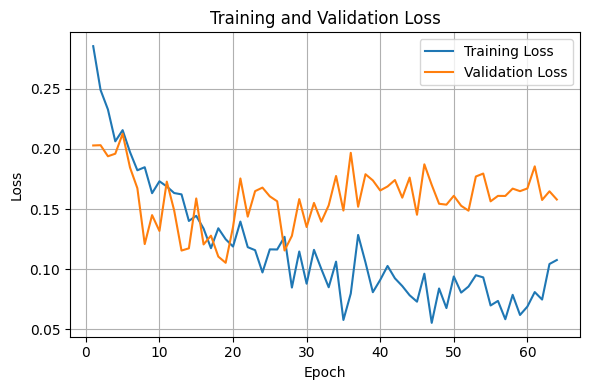

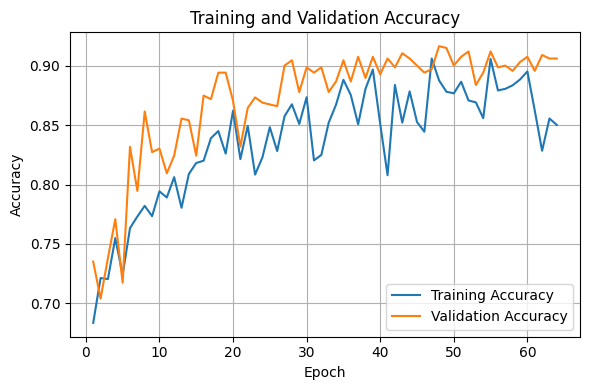

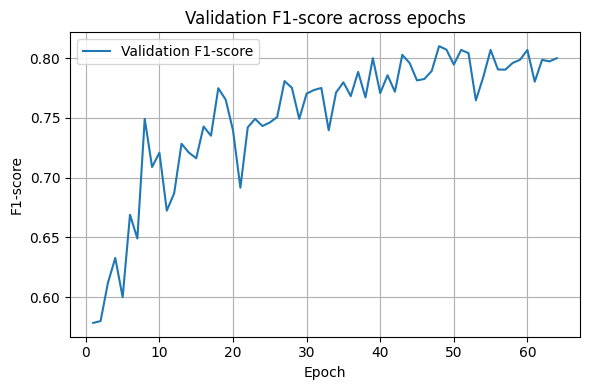

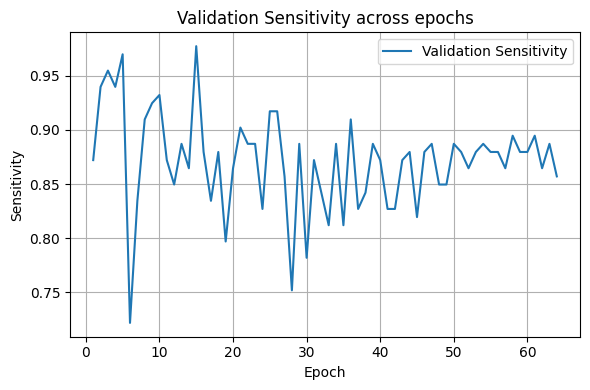

In [72]:
if __name__ == "__main__":
    # Train model với config hiện tại
    main(current_config)

    # Sau khi train xong, tự động test trên tập validation riêng (nếu có file)
    base_dir = Path(current_config['trainer']['save_dir']) / "models" / current_config['name']


# Test

In [73]:
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
import pandas as pd

def test_model(config, best_model_path, validation_fea_path, validation_label_csv, criterion=None):
    config_parser = ConfigParser(config)
    device, _ = prepare_device(config_parser['n_gpu'])

    # 1. Khởi tạo model từ kiến trúc trong config
    model = config_parser.init_obj('arch', globals())
    model = model.to(device)

    # 2. Load Weights (Safe Mode)
    try:
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint)
        print("Loaded model weights with weights_only=True (safe mode)")
    except Exception as e:
        print(f"Safe load failed, trying full checkpoint load... Error: {e}")
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
        else:
            model.load_state_dict(checkpoint)
        print("Loaded model from full checkpoint")

    model.eval()

    # --- IN THÔNG TIN KIẾN TRÚC ---
    print("\n=== MODEL ARCHITECTURE ===")
    print(model)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTrainable parameters: {trainable_params:,}")

    # 3. Setup Thông số Dữ liệu
    delta = config['data_loader']['args'].get('delta', False)
    n_mfcc = config['data_loader']['args'].get('n_mfcc', 39) # Mặc định 13 nếu không có
    # T_FIXED trong code xử lý của bạn là 333, đảm bảo khớp với TIME_FRAME
    time_frames = config['data_loader']['args'].get('time_frame', 333)

    channels = 3 if delta else 1
    height = n_mfcc

    # --- KIỂM TRA FORWARD PASS ---
    print("\n=== VERIFYING FORWARD PASS ===")
    try:
        with torch.no_grad():
            dummy_input = torch.randn(2, channels * height, time_frames).to(device)
            output = model(dummy_input)
            print(f"Input shape: (B, {channels * height}, {time_frames})")
            print(f"Output shape: {output.shape} → OK")
    except Exception as e:
        print(f"Forward pass error: {e}")

    # 4. Load Validation Data
    validation_label_df = pd.read_csv(validation_label_csv)
    validation_label_df['filename'] = validation_label_df['filename'].apply(lambda x: Path(x).stem)

    validation_dataset = HeartSoundDataSet(
        fea_path=validation_fea_path,
        labels=validation_label_df,
        duration=config['data_loader']['args']['duration'],
        training=False,
        delta=delta,
        norm=config['data_loader']['args'].get('norm', True)
    )

    # --- DEBUG: SAMPLE FEATURES ---
    print("\n=== DEBUG: SAMPLE FEATURES ===")
    for i in range(min(5, len(validation_dataset))):
        fea, lab = validation_dataset[i]
        print(f"Sample {i}: shape = {fea.shape}, label = {lab.item()}")

    validation_dataloader = DataLoader(
        validation_dataset,
        batch_size=config['data_loader']['args']['batch_size'],
        shuffle=False,
        num_workers=config['data_loader']['args'].get('num_workers', 2),
        pin_memory=(device.type == 'cuda')
    )

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    # 5. Đánh giá và thu thập kết quả
    all_probs = []   # Xác suất của class 1 (Abnormal)
    all_targets = []
    total_loss = 0.0

    print("\n=== EVALUATING ON VALIDATION SET ===")
    with torch.no_grad():
        for data, target in validation_dataloader:
            data, target = data.to(device).float(), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            total_loss += loss.item() * data.size(0)

            # Lấy xác suất lớp Abnormal (Class 1) để vẽ ROC
            probs = torch.softmax(output, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    # 6. Tính toán ROC và Tìm Threshold tối ưu (Youden Index)
    fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
    roc_auc = auc(fpr, tpr)

    # Threshold tốt nhất là nơi Sensitivity + Specificity cao nhất
    idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[idx]
    final_preds = (all_probs >= best_threshold).astype(int)

    # 7. Tính toán các chỉ số chi tiết
    cm = confusion_matrix(all_targets, final_preds)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)

    avg_loss = total_loss / len(all_targets)
    accuracy = (tp + tn) / len(all_targets)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    MAcc = (sensitivity + specificity) / 2
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    print(f"\n[RESULTS AT OPTIMAL THRESHOLD: {best_threshold:.4f}]")
    val_log = {
        'loss': avg_loss, 'accuracy': accuracy, 'sensitivity': sensitivity,
        'specificity': specificity, 'MAcc': MAcc, 'F1_score': f1, 'AUC': roc_auc
    }
    for k, v in val_log.items():
        print(f"    {k}: {v:.4f}")

    # 8. Vẽ ROC Curve và Confusion Matrix
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Vẽ ROC
    ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[0].scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'Best Threshold: {best_threshold:.2f}')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic')
    ax[0].legend(loc="lower right")

    # Vẽ Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
                xticklabels=['Normal (0)', 'Abnormal (1)'],
                yticklabels=['Normal (0)', 'Abnormal (1)'])
    ax[1].set_xlabel('Predicted Label')
    ax[1].set_ylabel('True Label')
    ax[1].set_title(f'Confusion Matrix at Threshold {best_threshold:.2f}')

    plt.tight_layout()
    save_img_path = Path(best_model_path).parent / "evaluation_results_detailed.png"
    plt.savefig(save_img_path, dpi=300)
    plt.show()

    # 9. Lưu báo cáo và CSV
    print("\nClassification Report:")
    print(classification_report(all_targets, final_preds, target_names=['Normal', 'Abnormal']))

    metrics_path = Path(best_model_path).parent / "test_evaluation_metrics.csv"
    pd.DataFrame([val_log]).to_csv(metrics_path, index=False)
    print(f"\nResults saved at: {metrics_path}")

    return val_log

In [74]:
val_df = pd.read_csv(str(DATASET_PATH / 'label_39_validation.csv'))
print("\n=== PHÂN PHỐI LABEL (test/val set) ===")
print(val_df['label'].value_counts())
print(f"Tỷ lệ Abnormal: {val_df['label'].mean():.2%}")


=== PHÂN PHỐI LABEL (test/val set) ===
label
1    151
0    150
Name: count, dtype: int64
Tỷ lệ Abnormal: 50.17%


Safe load failed, trying full checkpoint load... Error: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the docume

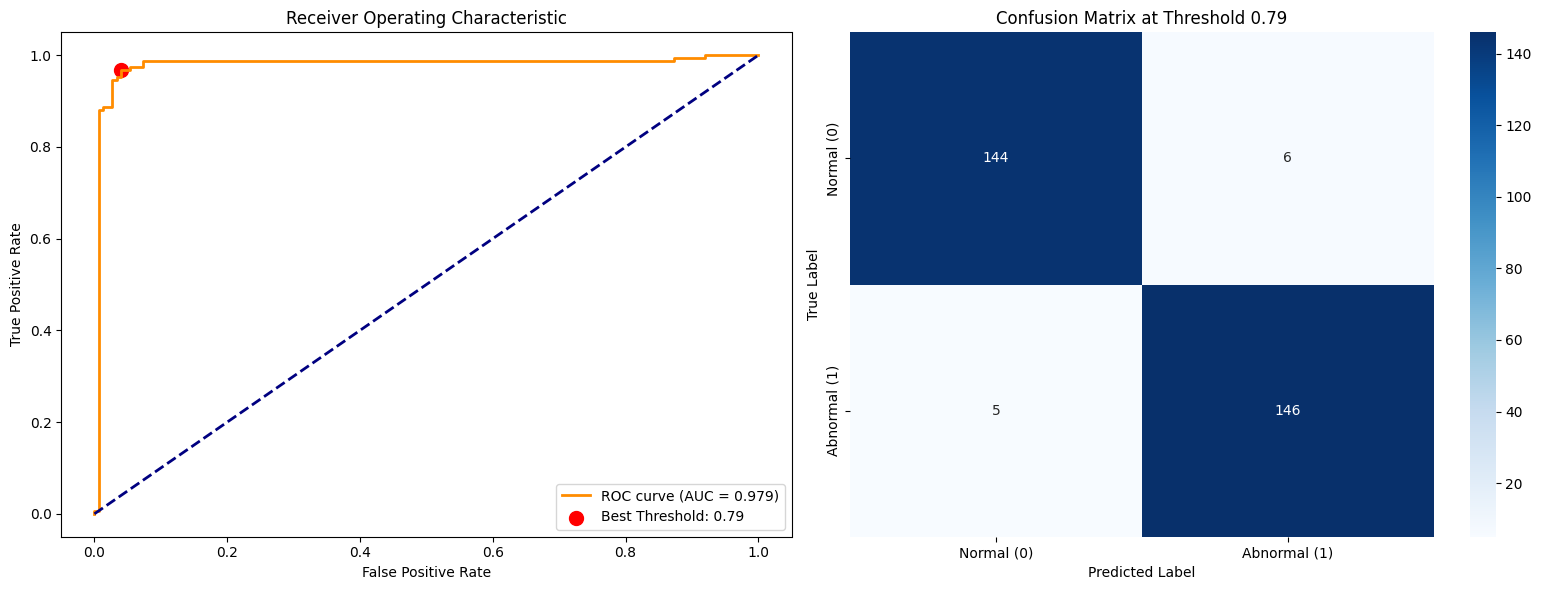


Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.96       150
    Abnormal       0.96      0.97      0.96       151

    accuracy                           0.96       301
   macro avg       0.96      0.96      0.96       301
weighted avg       0.96      0.96      0.96       301


Results saved at: /content/drive/MyDrive/AutomaticHeartSoundClassification-main/saved/xception/models/Physionet_Xception/0403_012446/test_evaluation_metrics.csv
Model size: 0.60 MB


In [75]:
base_dir = Path(current_config['trainer']['save_dir']) / "models" / current_config['name']
if base_dir.exists():
        latest_run = max(base_dir.iterdir(), key=os.path.getmtime)
        best_model_path = latest_run / "model_best.pth"

        validation_fea_path = str(DATASET_PATH / "mfcc_39_features_validation.h5")
        validation_label_csv = str(DATASET_PATH / "label_39_validation.csv")  # Đảm bảo file này tồn tại!

        if Path(validation_fea_path).exists() and Path(validation_label_csv).exists():
            test_model(current_config, best_model_path, validation_fea_path, validation_label_csv)
        else:
            print("Không tìm thấy file validation .h5 hoặc label_validation.csv → Bỏ qua phần test.")

        size_bytes = os.path.getsize(best_model_path)
        size_mb = size_bytes / (1024 * 1024)

        print(f"Model size: {size_mb:.2f} MB")

else:
    print("Không tìm thấy thư mục saved models.")
